# **Домашнее задание: Self-Supervised & Contrastive Learning в Colab**
Автор: Харинова Софья Александровна

Группа: М-26

In [8]:
# import torch
# import gc

# def clear_memory():
#     torch.cuda.empty_cache()
#     gc.collect()
# clear_memory()

# Часть A: Предтекстовая задача - Раскрашивание (PackPacka)

## **Выбор задачи:** **раскрашивание (grayscale → RGB)**
## A1. Базовая постановка

### A1. Базовая постановка задачи PackPacka (grayscale → RGB)

**Постановка задачи:**
- **Вход модели:** Изображение в оттенках серого (grayscale), созданное усреднением каналов RGB
- **Цель модели:** Восстановить оригинальное цветное (RGB) изображение
- **Функция потерь:** MSE ( L2-лосс)
- **Архитектура:** Сверточная нейронная сеть encoder-decoder с skip-connections




In [9]:
import torch
import gc

def clear_memory():
    torch.cuda.empty_cache()
    gc.collect()
clear_memory()

In [10]:
import numpy as np
from tqdm import tqdm

import torch
from torch import nn
import torchvision.transforms as T
import torchvision.datasets as dsets
import torchvision.models as models
import torch.nn.functional as F
from torch.utils.data import DataLoader

from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from PIL import Image
import os
import sys


!{sys.executable} -m pip install -U transformers

# Настройка окружения
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(14)
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

####  Подготовка данных для раскрашивания

In [11]:
# Загружаем CIFAR-10
train_data = dsets.CIFAR10(root="./data", train=True, download=True)
test_data = dsets.CIFAR10(root="./data", train=False, download=True)

# Функция для создания grayscale из RGB
def rgb_to_grayscale_tensor(rgb_tensor):
    # Формула: Y = 0.299*R + 0.587*G + 0.114*B
    grayscale = 0.299 * rgb_tensor[0] + 0.587 * rgb_tensor[1] + 0.114 * rgb_tensor[2]
    return grayscale.unsqueeze(0)  # Добавляем dimension канала

# Преобразования
transform = T.Compose([
    T.ToTensor(),  # В тензор [0, 1]
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # В [-1, 1]
])

# Подготавливаем тренировочные данные
train_grayscale = []
train_rgb = []

print("Подготовка тренировочных данных")
for img, label in tqdm(train_data):
    # Преобразуем в тензор и нормализуем
    rgb_tensor = transform(img)

    # Создаем grayscale версию
    gray_tensor = rgb_to_grayscale_tensor(rgb_tensor)

    # Сохраняем
    train_grayscale.append(gray_tensor)
    train_rgb.append(rgb_tensor)

# Подготавливаем тестовые данные
test_grayscale = []
test_rgb = []
test_labels = []

print("Подготовка тестовых данных")
for img, label in tqdm(test_data):
    rgb_tensor = transform(img)
    gray_tensor = rgb_to_grayscale_tensor(rgb_tensor)

    test_grayscale.append(gray_tensor)
    test_rgb.append(rgb_tensor)
    test_labels.append(label)

# 6. Создаем DataLoader для обучения
train_dataset = list(zip(train_grayscale, train_rgb))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)

print(f"Тренировочных примеров: {len(train_grayscale)}")
print(f"Тестовых примеров: {len(test_grayscale)}")

Подготовка тренировочных данных


100%|██████████| 50000/50000 [00:41<00:00, 1207.54it/s]


Подготовка тестовых данных


100%|██████████| 10000/10000 [00:03<00:00, 2639.64it/s]

Тренировочных примеров: 50000
Тестовых примеров: 10000


#### Создание модели для раскрашивания

In [12]:
print("Создание модели для ")

def create_simple_model():
    model = nn.Sequential(
        # Вход: 1 канал grayscale, выход: 3 канала
        nn.Conv2d(1, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, padding=1),
        nn.ReLU(),

        nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.ReLU(),

        nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
        nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, padding=1),
        nn.ReLU(),

        nn.Conv2d(32, 3, kernel_size=3, padding=1),
        nn.Tanh()  # Выход в диапазоне [-1, 1]
    )
    return model

# Создаем модель
model_a1 = create_simple_model().to(device)
print(f"Модель создана. Параметров: {sum(p.numel() for p in model_a1.parameters()):,}")

Создание модели для 
Модель создана. Параметров: 83,331


#### Обучение модели

In [13]:
print("Обучение модели A1 с MSE loss")
def train_model_mse(model, train_loader, epochs=3):

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch_idx, (gray_batch, rgb_batch) in enumerate(tqdm(train_loader,
                                                                 desc=f"Эпоха {epoch+1}/{epochs}")):
            # Перемещаем данные на устройство
            gray_batch = gray_batch.to(device)
            rgb_batch = rgb_batch.to(device)

            # Forward pass
            predictions = model(gray_batch)

            # Вычисляем MSE loss
            loss = F.mse_loss(predictions, rgb_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Логирование каждые 100 батчей
            if batch_idx % 100 == 0:
                print(f"  Батч {batch_idx}: MSE Loss = {loss.item():.4f}")

        # Средний loss за эпоху
        avg_loss = total_loss / len(train_loader)
        print(f"Эпоха {epoch+1} завершена. Средний MSE loss: {avg_loss:.4f}\n")

    return model

# Обучаем модель
model_a1 = train_model_mse(model_a1, train_loader, epochs=3)

# Сохраняем модель A1
torch.save(model_a1.state_dict(), 'model_a1_mse.pth')


Обучение модели A1 с MSE loss


Эпоха 1/3:   0%|          | 1/782 [00:00<07:11,  1.81it/s]

  Батч 0: MSE Loss = 0.2654


Эпоха 1/3:  13%|█▎        | 101/782 [00:56<04:22,  2.59it/s]

  Батч 100: MSE Loss = 0.0424


...

  Батч 600: MSE Loss = 0.0198


Эпоха 3/3:  90%|████████▉ | 701/782 [04:10<00:26,  3.00it/s]

  Батч 700: MSE Loss = 0.0198


Эпоха 3/3: 100%|██████████| 782/782 [04:38<00:00,  2.80it/s]

Эпоха 3 завершена. Средний MSE loss: 0.0234



In [14]:
print("Тестирование модели A1")

def test_model(model, test_grayscale, test_rgb, num_samples=100):
    model.eval()

    # случайные примеры для теста
    indices = np.random.choice(len(test_grayscale), num_samples, replace=False)

    psnr_values = []
    ssim_values = []
    predictions = []

    with torch.no_grad():
        for idx in tqdm(indices, desc="Тестирование"):
            # Получаем данные
            gray_tensor = test_grayscale[idx].unsqueeze(0).to(device)
            rgb_tensor = test_rgb[idx].unsqueeze(0).to(device)

            # Получаем предсказание
            pred_tensor = model(gray_tensor)

            # Конвертируем в numpy для вычисления метрик
            pred_np = pred_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
            target_np = rgb_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)

            # Для grayscale
            gray_np = gray_tensor.squeeze().cpu().numpy()
            if gray_np.ndim == 3:
                gray_np = gray_np.squeeze()  # Если есть канал, удаляем его

            # Денормализуем из [-1, 1] в [0, 1]
            pred_np = (pred_np * 0.5 + 0.5).clip(0, 1)
            target_np = (target_np * 0.5 + 0.5).clip(0, 1)
            gray_np = (gray_np * 0.5 + 0.5).clip(0, 1)

            #  PSNR
            psnr = peak_signal_noise_ratio(target_np, pred_np, data_range=1.0)
            psnr_values.append(psnr)

            #  SSIM (усредняем по каналам)
            ssim_channels = []
            for c in range(3):  # Для каждого RGB канала
                ssim_c = structural_similarity(
                    target_np[:, :, c], pred_np[:, :, c],
                    data_range=1.0, gaussian_weights=True
                )
                ssim_channels.append(ssim_c)
            ssim = np.mean(ssim_channels)
            ssim_values.append(ssim)

            #  для визуализации
            predictions.append({
                'gray': gray_np,
                'pred': pred_np,
                'target': target_np,
                'psnr': psnr,
                'ssim': ssim
            })

    return predictions, psnr_values, ssim_values

# Тестируем модель A1
print("\nТестирование модели A1 на 100 примерах")
predictions_a1, psnr_a1, ssim_a1 = test_model(model_a1, test_grayscale, test_rgb, num_samples=100)

# Выводим метрики

print("РЕЗУЛЬТАТЫ A1 (Только MSE loss):")

print(f"Средний PSNR: {np.mean(psnr_a1):.2f} dB")
print(f"Средний SSIM: {np.mean(ssim_a1):.3f}")
print(f"Лучший PSNR: {np.max(psnr_a1):.2f} dB")
print(f"Худший PSNR: {np.min(psnr_a1):.2f} dB")
print(f"Лучший SSIM: {np.max(ssim_a1):.3f}")
print(f"Худший SSIM: {np.min(ssim_a1):.3f}")


Тестирование модели A1

Тестирование модели A1 на 100 примерах


Тестирование: 100%|██████████| 100/100 [00:00<00:00, 173.49it/s]

РЕЗУЛЬТАТЫ A1 (Только MSE loss):
Средний PSNR: 23.51 dB
Средний SSIM: 0.920
Лучший PSNR: 31.39 dB
Худший PSNR: 12.56 dB
Лучший SSIM: 0.991
Худший SSIM: 0.667


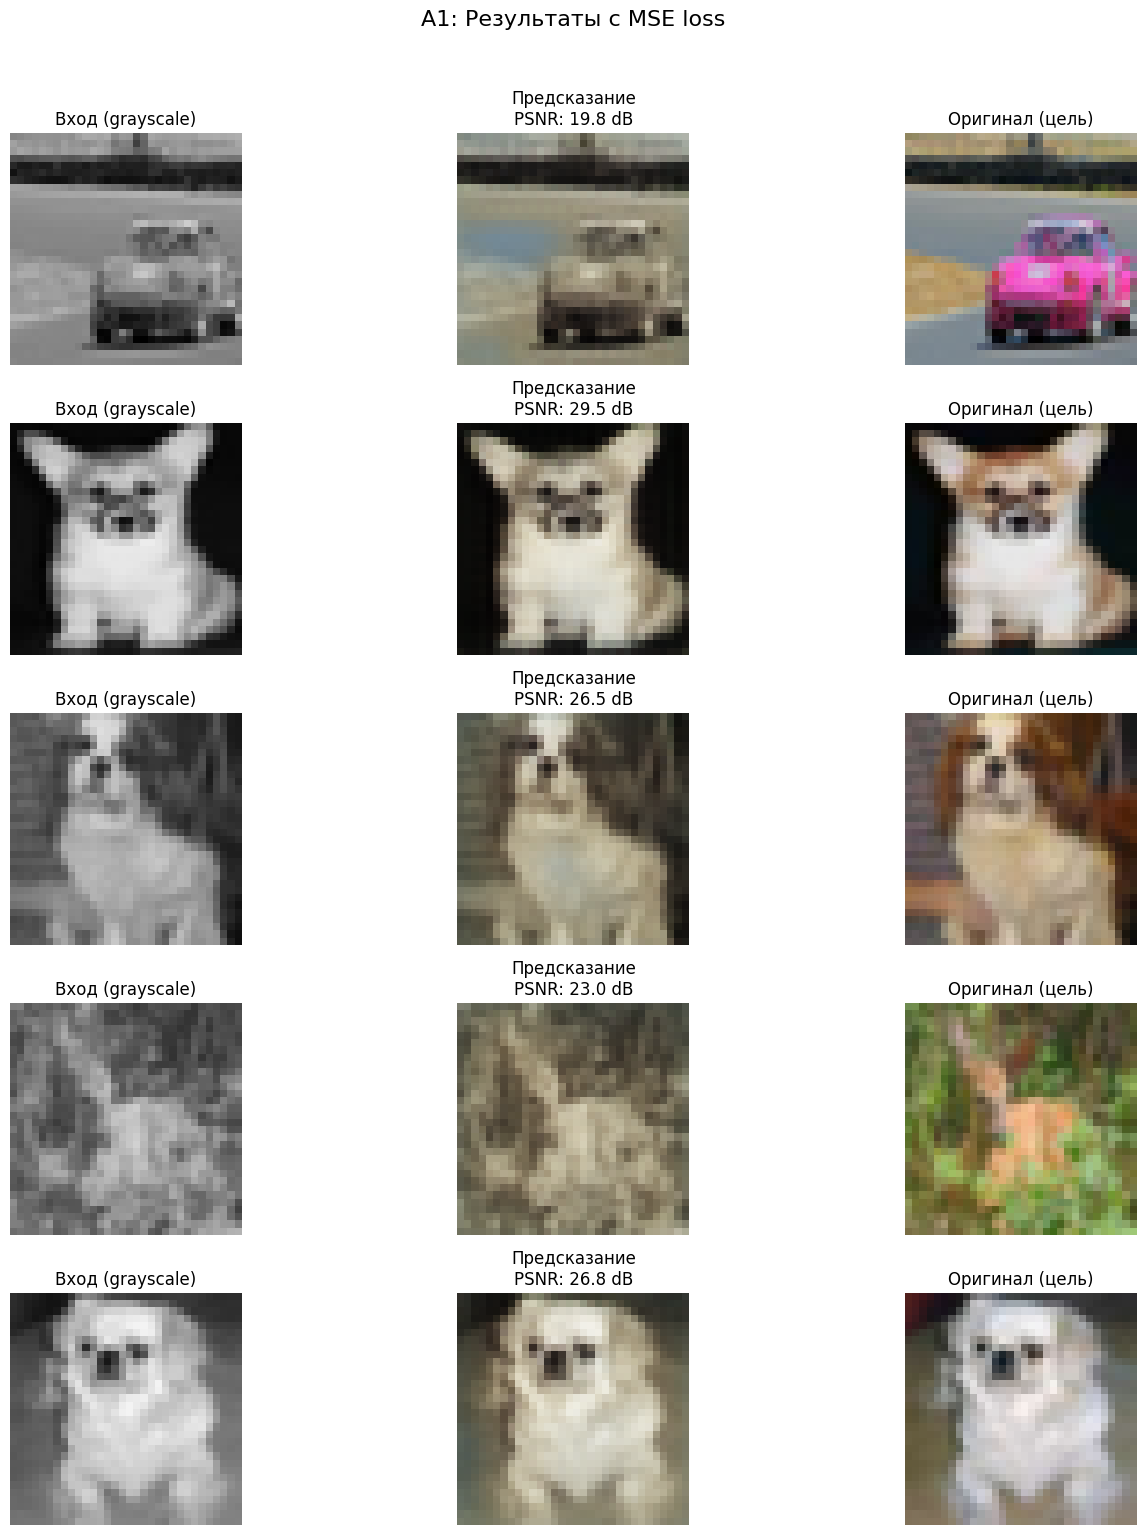

In [15]:
def visualize_predictions(predictions, title="Результаты A1", num_samples=5):
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 3*num_samples))
    fig.suptitle(title, fontsize=16, y=1.02)

    # случайные примеры для отображения
    indices = np.random.choice(len(predictions), min(num_samples, len(predictions)), replace=False)

    for i, idx in enumerate(indices):
        sample = predictions[idx]

        # Отображаем grayscale вход
        axes[i, 0].imshow(sample['gray'], cmap='gray', vmin=0, vmax=1)
        axes[i, 0].set_title("Вход (grayscale)")
        axes[i, 0].axis('off')
        # Отображаем предсказание модели
        axes[i, 1].imshow(sample['pred'])
        axes[i, 1].set_title(f"Предсказание\nPSNR: {sample['psnr']:.1f} dB")
        axes[i, 1].axis('off')

        # Отображаем оригинал
        axes[i, 2].imshow(sample['target'])
        axes[i, 2].set_title("Оригинал (цель)")
        axes[i, 2].axis('off')


    plt.tight_layout()
    plt.show()

visualize_predictions(predictions_a1, title="A1: Результаты с MSE loss", num_samples=5)

Почему простой L2 (MSE) даёт «размытие» и усреднение?
Для одного grayscale изображения существует множество возможных цветных версий.
Модель с MSE loss стремится предсказать среднее всех возможных цветных вариантов. Поэтому:
   - Цвета становятся ненасыщенными, "мыльными"
   - Границы размываются (усреднение различных границ)
   - Текстуры теряют чёткость
   - Общая картинка выглядит "замыленной"
   
MSE loss заставляет модель быть "осторожной" и предсказывать усреднённые,
ненасыщенные цвета, что приводит к размытым, неярким результатам.


### **A2. Улучшение лосса**

In [16]:
import torchvision.models as models

In [17]:
print("Создание улучшенной модели для А2")

def create_a2_model_perceptual():
    model = nn.Sequential(
        # энкодер
        nn.Conv2d(1, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),  # 32x32 -> 16x16

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),  # 16x16 -> 8x8

        #
        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),

        # декодер
        nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),  # 8x8 -> 16x16
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),

        nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # 16x16 -> 32x32
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),

        # результат
        nn.Conv2d(64, 32, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(32, 3, kernel_size=3, padding=1),
        nn.Tanh()  # Выход в [-1, 1]
    )
    return model

# Создаем модель А2
model_a2 = create_a2_model_perceptual().to(device)
print(f"Модель А2 создана. Параметров: {sum(p.numel() for p in model_a2.parameters()):,}")

Создание улучшенной модели для А2
Модель А2 создана. Параметров: 1,514,307


### Создание перцептивного лосса

In [18]:
print("Создание перцептивного лосса")
def create_perceptual_loss_model():
    vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
    for param in vgg.parameters():
        param.requires_grad = False
    vgg = vgg[:9]  # До слоя 'conv2_2'
    vgg.eval()

    return vgg.to(device)
perceptual_model = create_perceptual_loss_model()
print("Перцептивный лосс создан ")

Создание перцептивного лосса
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 66.1MB/s]


Перцептивный лосс создан 


### Функция потерь для А2 (MSE + Perceptual)

In [19]:
print("Создание функции потерь для А2 (MSE + Perceptual)")

def compute_perceptual_loss(pred, target, perceptual_model, lambda_mse=1.0, lambda_perceptual=0.1):
    # MSE Loss
    mse_loss = F.mse_loss(pred, target)
    # Perceptual Loss
    pred_norm = (pred + 1) / 2
    target_norm = (target + 1) / 2

    # ImageNet нормализация для VGG
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
    pred_vgg = (pred_norm - mean) / std
    target_vgg = (target_norm - mean) / std

    # признаки
    with torch.no_grad():
        features_pred = perceptual_model(pred_vgg)
        features_target = perceptual_model(target_vgg)
    perceptual_loss = F.mse_loss(features_pred, features_target)

    total_loss = lambda_mse * mse_loss + lambda_perceptual * perceptual_loss

    return total_loss, mse_loss, perceptual_loss

Создание функции потерь для А2 (MSE + Perceptual)


#### Обучение модели

In [20]:
print("Обучение модели А2 с Perceptual Loss")

def train_a2_model_perceptual(model, perceptual_model, train_loader, epochs=3):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Для логирования
    total_losses = []
    mse_losses = []
    perceptual_losses = []

    for epoch in range(epochs):
        model.train()

        epoch_total = 0
        epoch_mse = 0
        epoch_perceptual = 0

        for batch_idx, (gray_batch, rgb_batch) in enumerate(tqdm(train_loader,
                                                                 desc=f"A2 Эпоха {epoch+1}/{epochs}")):
            # Перемещаем данные
            gray_batch = gray_batch.to(device)
            rgb_batch = rgb_batch.to(device)

            predictions = model(gray_batch)

            # Вычисляем loss
            total_loss, mse_loss, perceptual_loss = compute_perceptual_loss(
                predictions, rgb_batch, perceptual_model,
                lambda_mse=1.0, lambda_perceptual=0.1
            )

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            epoch_total += total_loss.item()
            epoch_mse += mse_loss.item()
            epoch_perceptual += perceptual_loss.item()

            # Логирование
            if batch_idx % 200 == 0:
                print(f"  Батч {batch_idx}: Total={total_loss.item():.4f}, "
                      f"MSE={mse_loss.item():.4f}, Perceptual={perceptual_loss.item():.4f}")

        # Средние значения за эпоху
        avg_total = epoch_total / len(train_loader)
        avg_mse = epoch_mse / len(train_loader)
        avg_perceptual = epoch_perceptual / len(train_loader)

        total_losses.append(avg_total)
        mse_losses.append(avg_mse)
        perceptual_losses.append(avg_perceptual)

        print(f"\nЭпоха {epoch+1} завершена:")
        print(f"  Total Loss: {avg_total:.4f}")
        print(f"  MSE Loss: {avg_mse:.4f}")
        print(f"  Perceptual Loss: {avg_perceptual:.4f}")
        print("-" * 50)



    return model

print("Начало обучения модели А2")
model_a2 = train_a2_model_perceptual(model_a2, perceptual_model, train_loader, epochs=3)

# Сохраняем модель А2
torch.save(model_a2.state_dict(), 'model_a2_perceptual.pth')


Обучение модели А2 с Perceptual Loss
Начало обучения модели А2


A2 Эпоха 1/3:   0%|          | 1/782 [00:03<44:36,  3.43s/it]

  Батч 0: Total=1.2699, MSE=0.2691, Perceptual=10.0083


A2 Эпоха 1/3:  26%|██▌       | 201/782 [08:43<24:46,  2.56s/it]

  Батч 200: Total=0.6366, MSE=0.0408, Perceptual=5.9579


...

  Батч 400: Total=0.3380, MSE=0.0244, Perceptual=3.1355


A2 Эпоха 3/3:  77%|███████▋  | 601/782 [26:08<08:33,  2.83s/it]

  Батч 600: Total=0.3608, MSE=0.0231, Perceptual=3.3770


A2 Эпоха 3/3: 100%|██████████| 782/782 [34:00<00:00,  2.61s/it]


Эпоха 3 завершена:
  Total Loss: 0.3677
  MSE Loss: 0.0252
  Perceptual Loss: 3.4247
--------------------------------------------------


Тестирование модели А2...


Тестирование: 100%|██████████| 100/100 [00:02<00:00, 40.54it/s]



РЕЗУЛЬТАТЫ А2 (MSE + Perceptual Loss):
Средний PSNR: 23.46 dB
Средний SSIM: 0.894
Лучший PSNR: 28.25 dB
Худший PSNR: 18.37 dB
Лучший SSIM: 0.973
Худший SSIM: 0.712


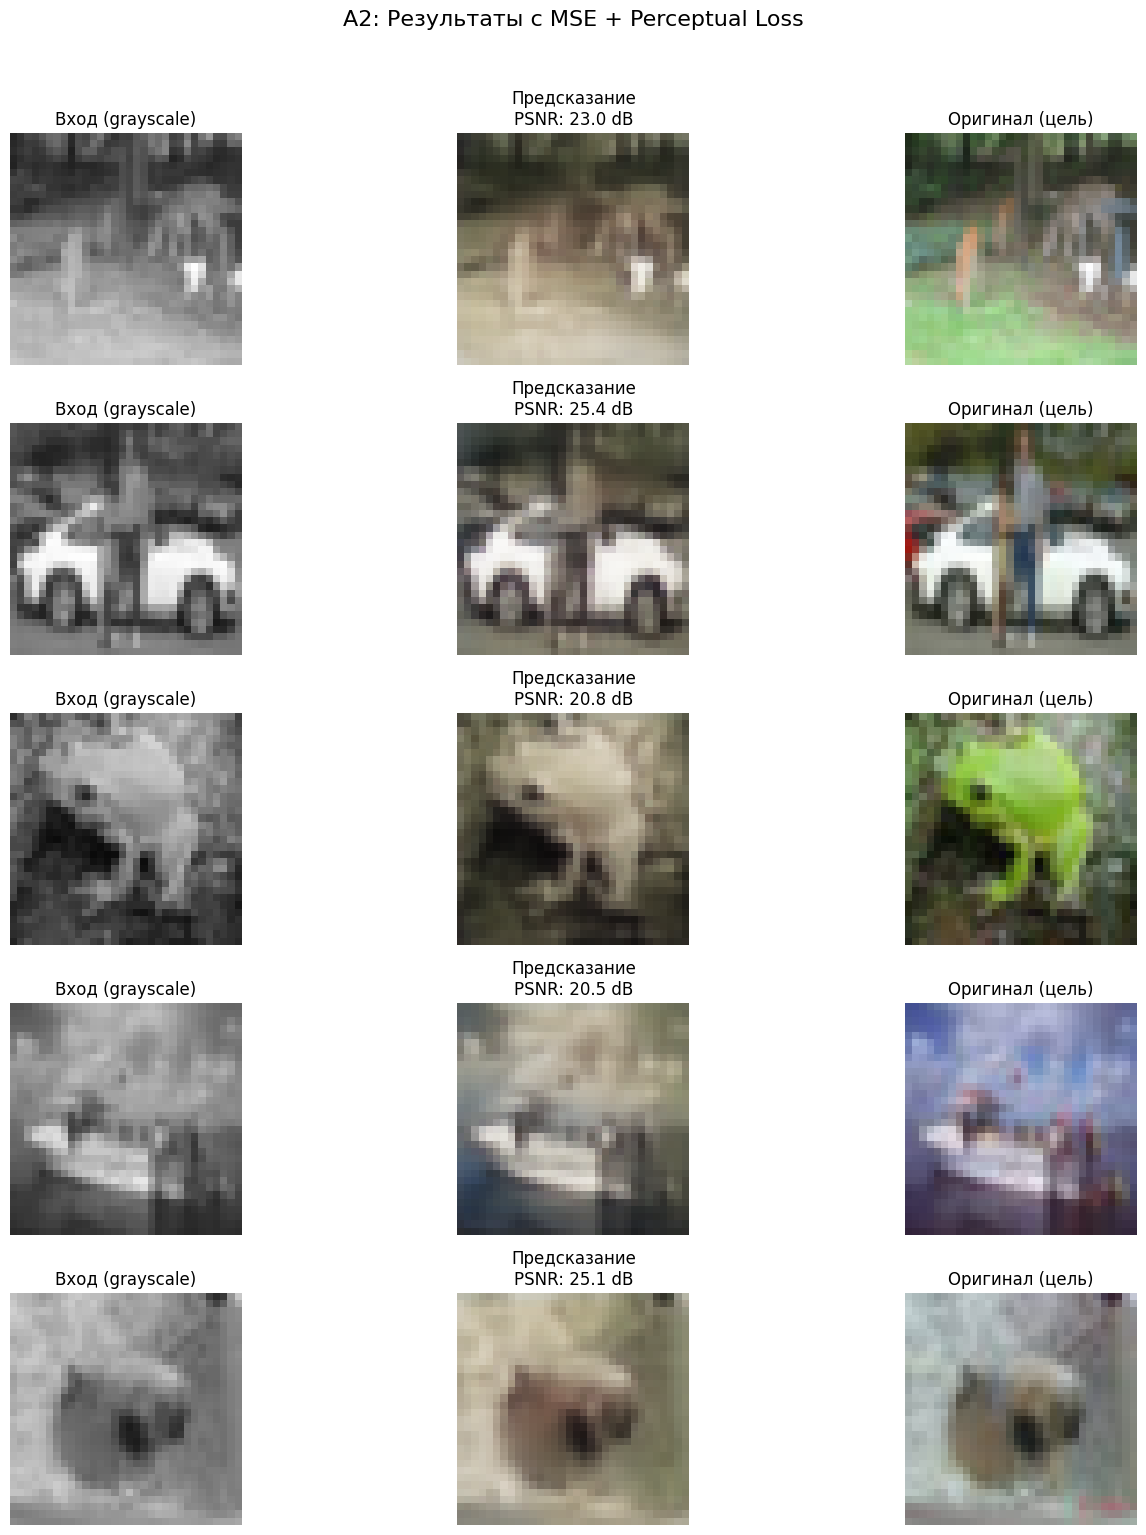

In [21]:
print("Тестирование модели А2...")
predictions_a2, psnr_a2, ssim_a2 = test_model(model_a2, test_grayscale, test_rgb, num_samples=100)

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ А2 (MSE + Perceptual Loss):")
print("="*50)
print(f"Средний PSNR: {np.mean(psnr_a2):.2f} dB")
print(f"Средний SSIM: {np.mean(ssim_a2):.3f}")
print(f"Лучший PSNR: {np.max(psnr_a2):.2f} dB")
print(f"Худший PSNR: {np.min(psnr_a2):.2f} dB")
print(f"Лучший SSIM: {np.max(ssim_a2):.3f}")
print(f"Худший SSIM: {np.min(ssim_a2):.3f}")
print("="*50)

visualize_predictions(predictions_a2, title="A2: Результаты с MSE + Perceptual Loss", num_samples=5)

Визуальное сравнение A1 и A2 на одних и тех же примерах


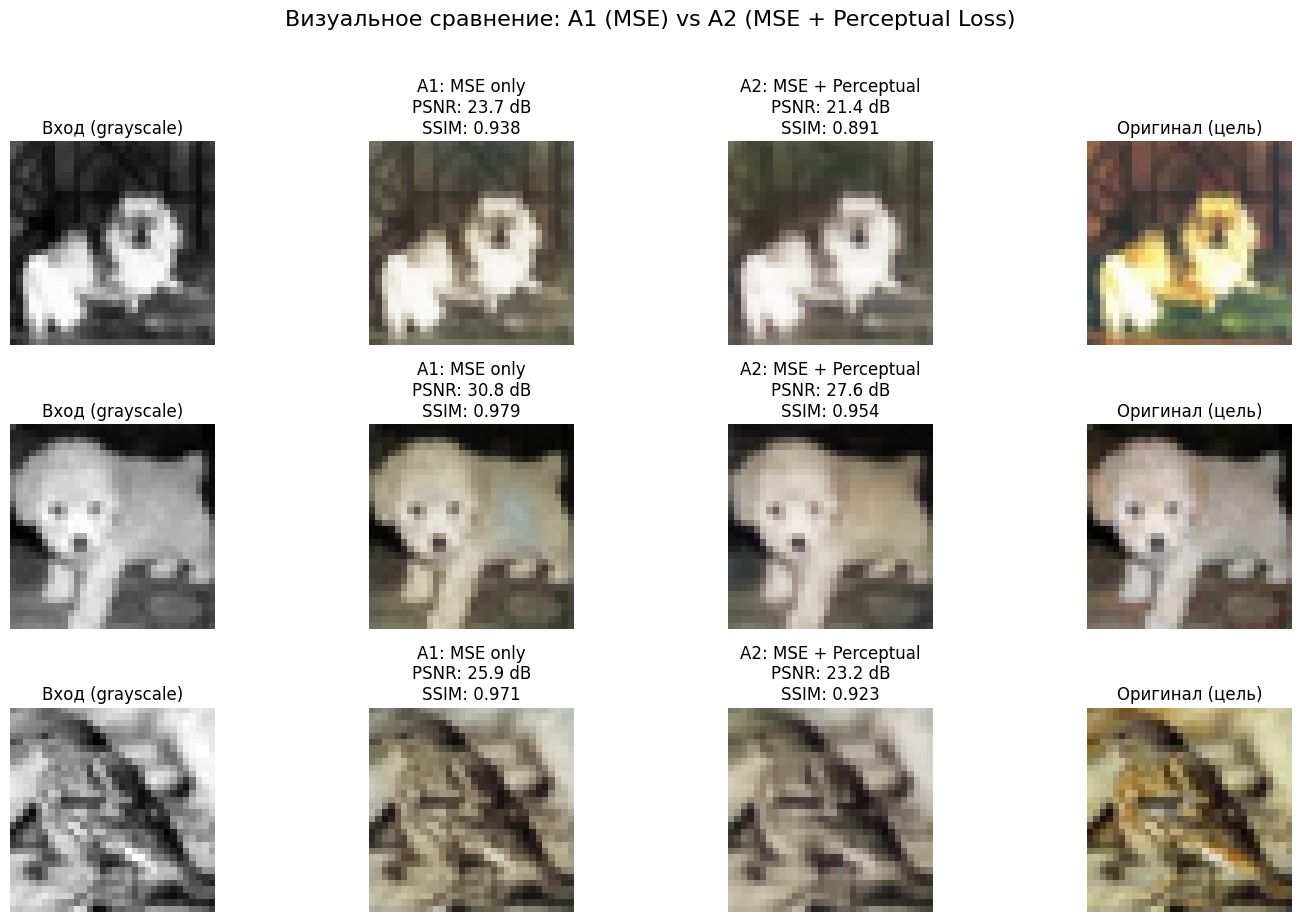

In [22]:
print("Визуальное сравнение A1 и A2 на одних и тех же примерах")

def compare_models_side_by_side(model_a1, model_a2, test_grayscale, test_rgb, num_samples=3):
    indices = np.random.choice(len(test_grayscale), num_samples, replace=False)

    fig, axes = plt.subplots(num_samples, 4, figsize=(15, 3*num_samples))
    fig.suptitle('Визуальное сравнение: A1 (MSE) vs A2 (MSE + Perceptual Loss)',
                 fontsize=16, y=1.02)

    for i, idx in enumerate(indices):
        #  данные
        gray_tensor = test_grayscale[idx].unsqueeze(0).to(device)
        rgb_tensor = test_rgb[idx].unsqueeze(0).to(device)

        #  предсказания
        with torch.no_grad():
            pred_a1 = model_a1(gray_tensor)
            pred_a2 = model_a2(gray_tensor)

        gray_np = gray_tensor.squeeze().cpu().numpy()
        if gray_np.ndim == 3:
            gray_np = gray_np.squeeze()

        target_np = rgb_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
        pred_a1_np = pred_a1.squeeze().cpu().numpy().transpose(1, 2, 0)
        pred_a2_np = pred_a2.squeeze().cpu().numpy().transpose(1, 2, 0)

        # Денормализуем
        gray_np = (gray_np * 0.5 + 0.5).clip(0, 1)
        target_np = (target_np * 0.5 + 0.5).clip(0, 1)
        pred_a1_np = (pred_a1_np * 0.5 + 0.5).clip(0, 1)
        pred_a2_np = (pred_a2_np * 0.5 + 0.5).clip(0, 1)

        # Вычисляем метрики
        psnr_a1_val = peak_signal_noise_ratio(target_np, pred_a1_np, data_range=1.0)
        psnr_a2_val = peak_signal_noise_ratio(target_np, pred_a2_np, data_range=1.0)

        ssim_a1_val = structural_similarity(target_np, pred_a1_np, channel_axis=2, data_range=1.0)
        ssim_a2_val = structural_similarity(target_np, pred_a2_np, channel_axis=2, data_range=1.0)

        # Визуализация
        axes[i, 0].imshow(gray_np, cmap='gray')
        axes[i, 0].set_title("Вход (grayscale)")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(pred_a1_np)
        axes[i, 1].set_title(f"A1: MSE only\nPSNR: {psnr_a1_val:.1f} dB\nSSIM: {ssim_a1_val:.3f}")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_a2_np)
        axes[i, 2].set_title(f"A2: MSE + Perceptual\nPSNR: {psnr_a2_val:.1f} dB\nSSIM: {ssim_a2_val:.3f}")
        axes[i, 2].axis('off')

        axes[i, 3].imshow(target_np)
        axes[i, 3].set_title("Оригинал (цель)")
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

    return {
        'indices': indices,
        'psnr_a1': [psnr_a1_val, psnr_a1_val, psnr_a1_val],
        'psnr_a2': [psnr_a2_val, psnr_a2_val, psnr_a2_val],
        'ssim_a1': [ssim_a1_val, ssim_a1_val, ssim_a1_val],
        'ssim_a2': [ssim_a2_val, ssim_a2_val, ssim_a2_val]
    }

comparison_results = compare_models_side_by_side(model_a1, model_a2, test_grayscale, test_rgb, num_samples=3)


Что улучшил добавленный перцептивный компонент (Perceptual Loss):
Цвета стали ярче и естественнее. Насыщенность: Увеличивается приближаясь к насыщенности оригиналов. A1: Усредняет все возможные цвета -> серые, ненасыщенные тона. A2: Лучше выбирает конкретные, правдоподобные цвета


## **A3. Краткий анализ ошибок**

In [23]:
 # Находит n худших предсказаний по PSNR
def find_worst_predictions(model, test_grayscale, test_rgb, n=10):

    model.eval()
    results = []

    with torch.no_grad():
        for i in tqdm(range(min(200, len(test_grayscale))), desc="Анализ ошибок"):
            gray = test_grayscale[i].unsqueeze(0).to(device)
            target = test_rgb[i].unsqueeze(0).to(device)

            pred = model(gray)

            # Конвертируем
            pred_np = pred.squeeze().cpu().numpy().transpose(1, 2, 0)
            target_np = target.squeeze().cpu().numpy().transpose(1, 2, 0)

            # Денормализуем
            pred_np = (pred_np * 0.5 + 0.5).clip(0, 1)
            target_np = (target_np * 0.5 + 0.5).clip(0, 1)

            # PSNR
            psnr = peak_signal_noise_ratio(target_np, pred_np, data_range=1.0)

            # Для grayscale
            gray_np = gray.squeeze().cpu().numpy()
            if gray_np.ndim == 3:
                gray_np = gray_np.squeeze()
            gray_np = (gray_np * 0.5 + 0.5).clip(0, 1)

            results.append({
                'idx': i,
                'gray': gray_np,
                'pred': pred_np,
                'target': target_np,
                'psnr': psnr
            })


    results.sort(key=lambda x: x['psnr'])
    return results[:n]

#  10 худших случаев
worst_cases = find_worst_predictions(model_a2, test_grayscale, test_rgb, n=10)
print(f"\nНайдено {len(worst_cases)} худших случаев")
print(f"PSNR: от {worst_cases[0]['psnr']:.1f} до {worst_cases[-1]['psnr']:.1f} dB")

Анализ ошибок: 100%|██████████| 200/200 [00:02<00:00, 71.56it/s]


Найдено 10 худших случаев
PSNR: от 13.7 до 16.5 dB



Визуализация неудачных кейсов


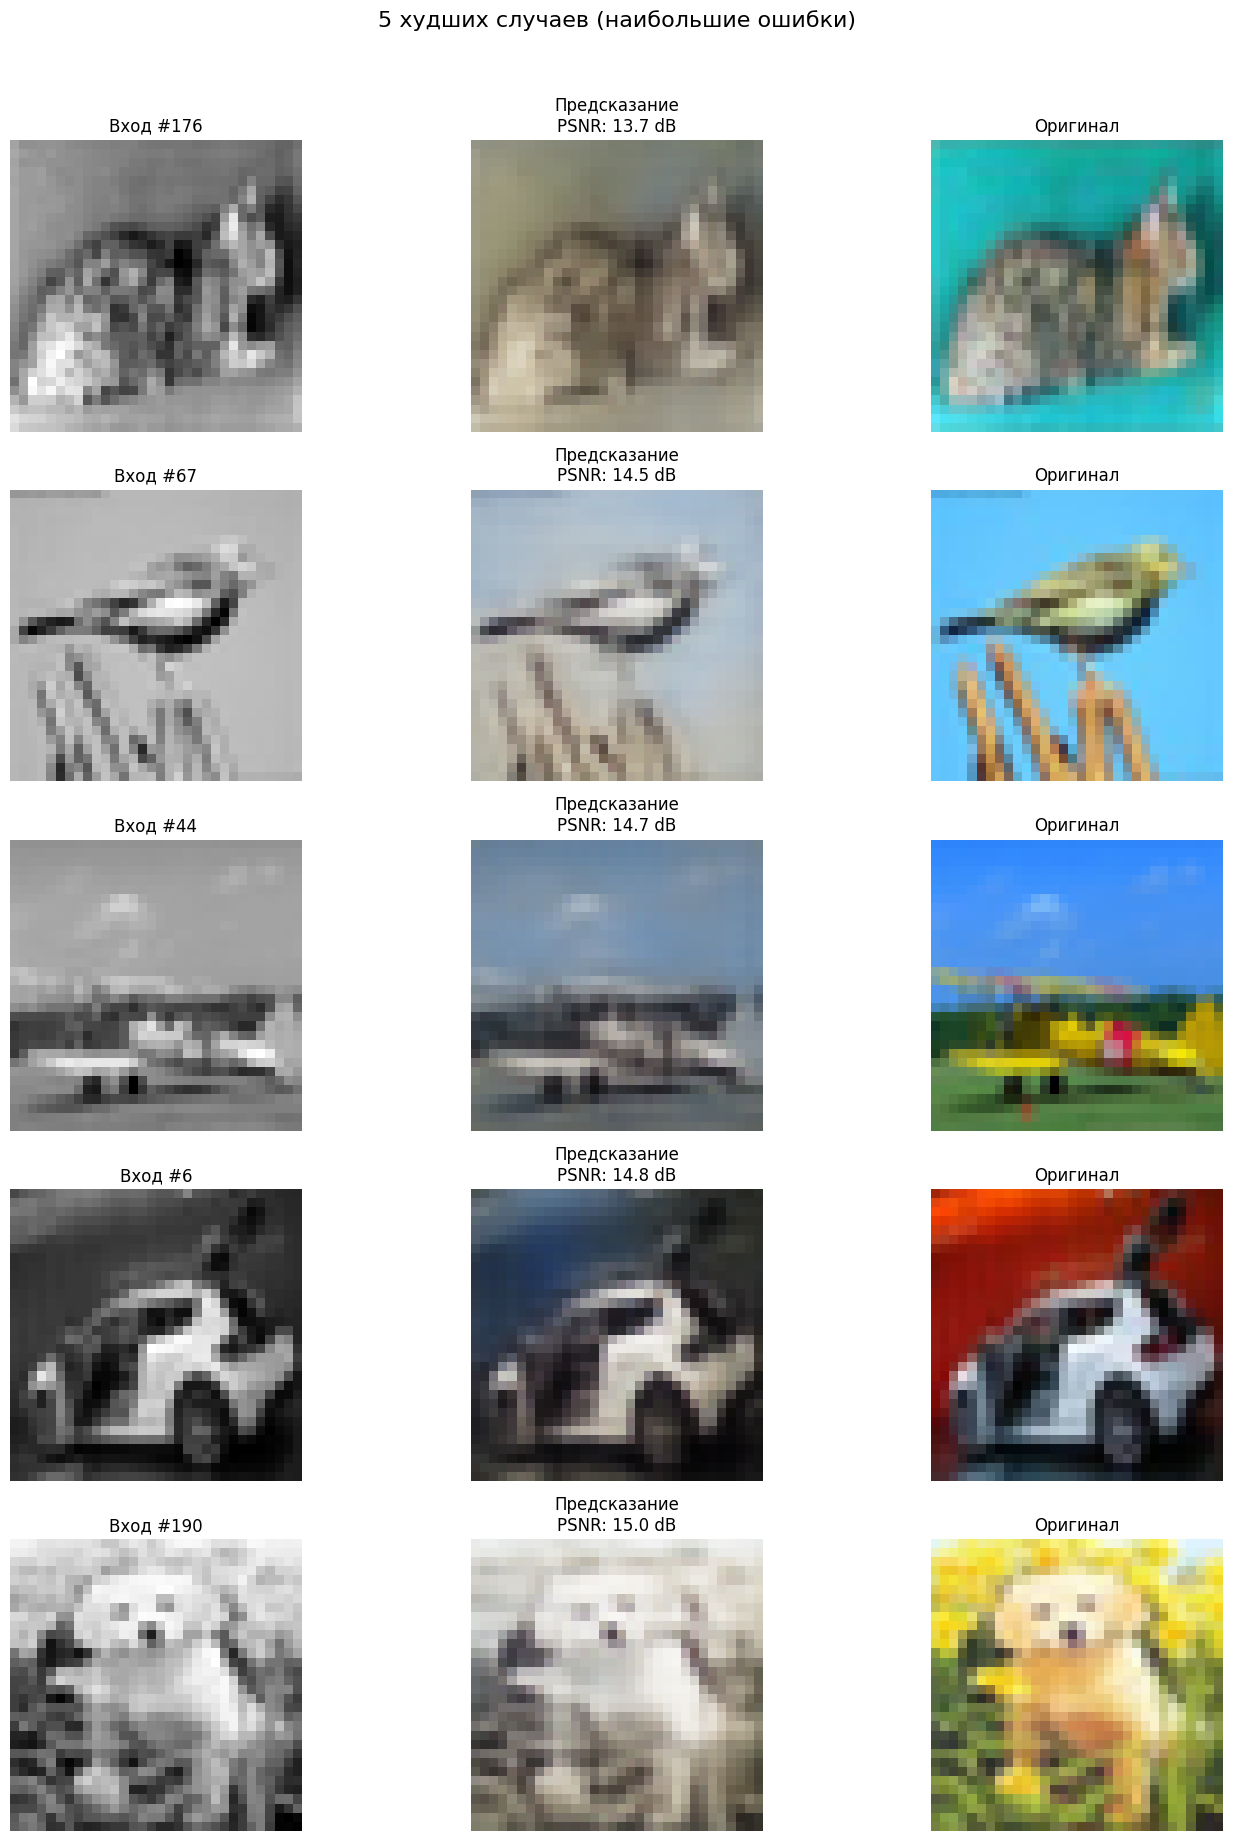

In [24]:
print("\nВизуализация неудачных кейсов")

fig, axes = plt.subplots(5, 3, figsize=(15, 18))

for i in range(5):
    if i >= len(worst_cases):
        break

    case = worst_cases[i]

    # Градации серого
    axes[i, 0].imshow(case['gray'], cmap='gray')
    axes[i, 0].set_title(f"Вход #{case['idx']}")
    axes[i, 0].axis('off')

    # Предсказание
    axes[i, 1].imshow(case['pred'])
    axes[i, 1].set_title(f"Предсказание\nPSNR: {case['psnr']:.1f} dB")
    axes[i, 1].axis('off')

    # Оригинал
    axes[i, 2].imshow(case['target'])
    axes[i, 2].set_title("Оригинал")
    axes[i, 2].axis('off')



plt.suptitle('5 худших случаев (наибольшие ошибки)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

ГИПОТЕЗЫ УЛУЧШЕНИЯ (2-3 предложения):

Добавить входные семантические маски или вектор класса объекта.Это снизит неоднозначность цветов для объектов. Уменьшит проблему усреднения цветов

Использовать признаки из ImageNet-предобученных классификаторов. Это даст модели больше семантической информации для правильного выбора цветов



## **Часть B (контрастивное обучение SimCLR-подобно)**

## **B1. Пайплайн и функция потерь**

In [25]:
# Аугментации для SimCLR
augmentations = T.Compose([
    # RandomResizedCrop - инвариантность к масштабу и позиции объекта
    T.RandomResizedCrop(size=32, scale=(0.8, 1.0)),

    # RandomHorizontalFlip - инвариантность к зеркальному отражению
    T.RandomHorizontalFlip(p=0.5),

    # ColorJitter - инвариантность к изменениям освещения и цвета
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),

    # RandomGrayscale - инвариантность к наличию/отсутствию цвета
    T.RandomGrayscale(p=0.2),

    # GaussianBlur - инвариантность к дефокусировке и шуму
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),

    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Аугментации созданы. Обоснование:")
print("1. RandomResizedCrop - инвариантность к масштабу и позиции")
print("2. RandomHorizontalFlip - инвариантность к отражению")
print("3. ColorJitter - инвариантность к цветовым искажениям")
print("4. RandomGrayscale - инвариантность к цвету")
print("5. GaussianBlur - инвариантность к дефокусировке")

print("\nПодготовка данных")
cifar_data = dsets.CIFAR10(root="./data", train=True, download=True)
contrastive_data = []
for img, _ in tqdm(cifar_data, desc="Создание пар"):
    view1 = augmentations(img)
    view2 = augmentations(img)
    contrastive_data.append((view1, view2))
batch_size = 256
contrastive_loader = DataLoader(contrastive_data, batch_size=batch_size, shuffle=True)

print(f"Создано {len(contrastive_data)} пар")
print(f"Batch size: {batch_size}")

Аугментации созданы. Обоснование:
1. RandomResizedCrop - инвариантность к масштабу и позиции
2. RandomHorizontalFlip - инвариантность к отражению
3. ColorJitter - инвариантность к цветовым искажениям
4. RandomGrayscale - инвариантность к цвету
5. GaussianBlur - инвариантность к дефокусировке

Подготовка данных


Создание пар: 100%|██████████| 50000/50000 [03:57<00:00, 210.40it/s]

Создано 50000 пар
Batch size: 256


In [26]:
print("\nСоздание энкодера")
encoder = nn.Sequential(
    nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten()
).to(device)

projection = nn.Sequential(
    nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 128)
).to(device)

print("Энкодер создан")
# =========== ЯЧЕЙКА: B1 InfoNCE функция потерь ===========
print("InfoNCE loss")

def info_nce_loss(z_i, z_j, temperature=0.5):
    batch_size = z_i.shape[0]
    z = torch.cat([z_i, z_j], dim=0)
    z = F.normalize(z, dim=1)
    sim_matrix = torch.matmul(z, z.T) / temperature

    # Маска для позитивных пар
    pos_mask = torch.zeros((2*batch_size, 2*batch_size), dtype=torch.bool, device=device)
    for i in range(batch_size):
        pos_mask[i, batch_size + i] = True
        pos_mask[batch_size + i, i] = True

    diag_mask = torch.eye(2*batch_size, dtype=torch.bool, device=device)
    sim_matrix = sim_matrix.masked_fill(diag_mask, -1e9)
    pos_sim = sim_matrix[pos_mask].view(2*batch_size, -1)
    neg_sim = sim_matrix[~pos_mask].view(2*batch_size, -1)


    numerator = pos_sim
    denominator = torch.logsumexp(neg_sim, dim=1, keepdim=True)

    # Loss
    loss = -numerator + denominator
    loss = loss.mean()

    return loss


Создание энкодера
Энкодер создан
InfoNCE loss


In [27]:
print("\nОбучение энкодера с InfoNCE loss")
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(projection.parameters()),
    lr=1e-3
)

# Обучение
epochs = 5
temperature = 0.5

for epoch in range(epochs):
    encoder.train()
    projection.train()

    epoch_loss = 0

    for batch_idx, (view1, view2) in enumerate(tqdm(contrastive_loader, desc=f"Эпоха {epoch+1}/{epochs}")):
        view1 = view1.to(device)
        view2 = view2.to(device)

        features1 = encoder(view1)
        features2 = encoder(view2)

        z1 = projection(features1)
        z2 = projection(features2)

        # loss
        loss = info_nce_loss(z1, z2, temperature=temperature)

        # Обновляем
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(contrastive_loader)
    print(f"Эпоха {epoch+1}: Loss = {avg_loss:.4f}")

print("Обучение завершено")


Обучение энкодера с InfoNCE loss


Эпоха 1/5: 100%|██████████| 196/196 [15:47<00:00,  4.84s/it]


Эпоха 1: Loss = 4.7857


Эпоха 2/5: 100%|██████████| 196/196 [16:16<00:00,  4.98s/it]


Эпоха 2: Loss = 4.5554


...

Эпоха 3: Loss = 4.5048


Эпоха 4/5: 100%|██████████| 196/196 [15:53<00:00,  4.87s/it]


Эпоха 4: Loss = 4.4818


Эпоха 5/5: 100%|██████████| 196/196 [15:59<00:00,  4.89s/it]

Эпоха 5: Loss = 4.4654
Обучение завершено


### Формула InfoNCE Loss

Функция потерь InfoNCE (Noise Contrastive Estimation):

$$
L_{InfoNCE} = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{\exp(\text{sim}(\mathbf{z}_i, \mathbf{z}_i^+)/\tau)}{\sum_{j=1}^{N} \exp(\text{sim}(\mathbf{z}_i, \mathbf{z}_j)/\tau)}
$$

где:
- $\text{sim}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|}$ — косинусная близость
- $\tau = 0.5$ — температура (гиперпараметр)
- $\mathbf{z}_i$ — эмбеддинг первого аугментированного вида
- $\mathbf{z}_i^+$ — эмбеддинг второго аугментированного вида (положительный пример)
- $\mathbf{z}_j$ — все остальные эмбеддинги в батче (отрицательные примеры)
- $N$ — размер батча



## **B2. Линейный probe**

In [28]:
cifar_train_labeled = dsets.CIFAR10(root="./data", train=True, download=True)
cifar_test_labeled = dsets.CIFAR10(root="./data", train=False, download=True)
probe_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Подготовка данных
train_features = []
train_labels = []
test_features = []
test_labels = []
encoder.eval()
with torch.no_grad():
    # Тренировочные данные
    for img, label in tqdm(cifar_train_labeled, desc="Тренировочные фичи"):
        img_tensor = probe_transform(img).unsqueeze(0).to(device)
        features = encoder(img_tensor)
        train_features.append(features.cpu())
        train_labels.append(label)

    # Тестовые данные
    for img, label in tqdm(cifar_test_labeled, desc="Тестовые фичи"):
        img_tensor = probe_transform(img).unsqueeze(0).to(device)
        features = encoder(img_tensor)
        test_features.append(features.cpu())
        test_labels.append(label)
train_features = torch.cat(train_features)
train_labels = torch.tensor(train_labels)
test_features = torch.cat(test_features)
test_labels = torch.tensor(test_labels)

print(f"Тренировочных фичей: {len(train_features)}")
print(f"Тестовых фичей: {len(test_features)}")

Тестовые фичи: 100%|██████████| 10000/10000 [00:55<00:00, 181.60it/s]


Тренировочных фичей: 50000
Тестовых фичей: 10000


In [29]:
print("\nСоздание линейного классификатора")
linear_probe = nn.Linear(512, 10).to(device)
probe_optimizer = torch.optim.Adam(linear_probe.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()


Создание линейного классификатора


In [30]:
print("\nОбучение линейного probe")

batch_size = 128
num_epochs = 10

train_dataset = torch.utils.data.TensorDataset(train_features, train_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(test_features, test_labels)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Обучение
accuracies = []
for epoch in range(num_epochs):
    linear_probe.train()
    total_loss = 0

    for batch_features, batch_labels in tqdm(train_loader, desc=f"Эпоха {epoch+1}/{num_epochs}", leave=False):
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = linear_probe(batch_features)
        loss = criterion(outputs, batch_labels)

        probe_optimizer.zero_grad()
        loss.backward()
        probe_optimizer.step()

        total_loss += loss.item()

    # Оценка точности
    linear_probe.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = linear_probe(batch_features)
            _, predicted = torch.max(outputs.data, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    accuracy = 100 * correct / total
    accuracies.append(accuracy)

    print(f"Эпоха {epoch+1}: Loss = {total_loss/len(train_loader):.4f}, "
          f"Accuracy = {accuracy:.2f}%")

print(f"\nЛучшая точность: {max(accuracies):.2f}%")


Обучение линейного probe


Эпоха 1: Loss = 1.4503, Accuracy = 50.60%


Эпоха 2: Loss = 1.3068, Accuracy = 54.59%


Эпоха 3: Loss = 1.2627, Accuracy = 56.76%


Эпоха 4: Loss = 1.2378, Accuracy = 55.28%


...

Эпоха 6: Loss = 1.2031, Accuracy = 58.31%


Эпоха 7: Loss = 1.1883, Accuracy = 54.01%


Эпоха 8: Loss = 1.1745, Accuracy = 57.20%


Эпоха 9: Loss = 1.1802, Accuracy = 58.44%


Эпоха 10: Loss = 1.1575, Accuracy = 56.11%

Лучшая точность: 58.44%



Матрица ошибок


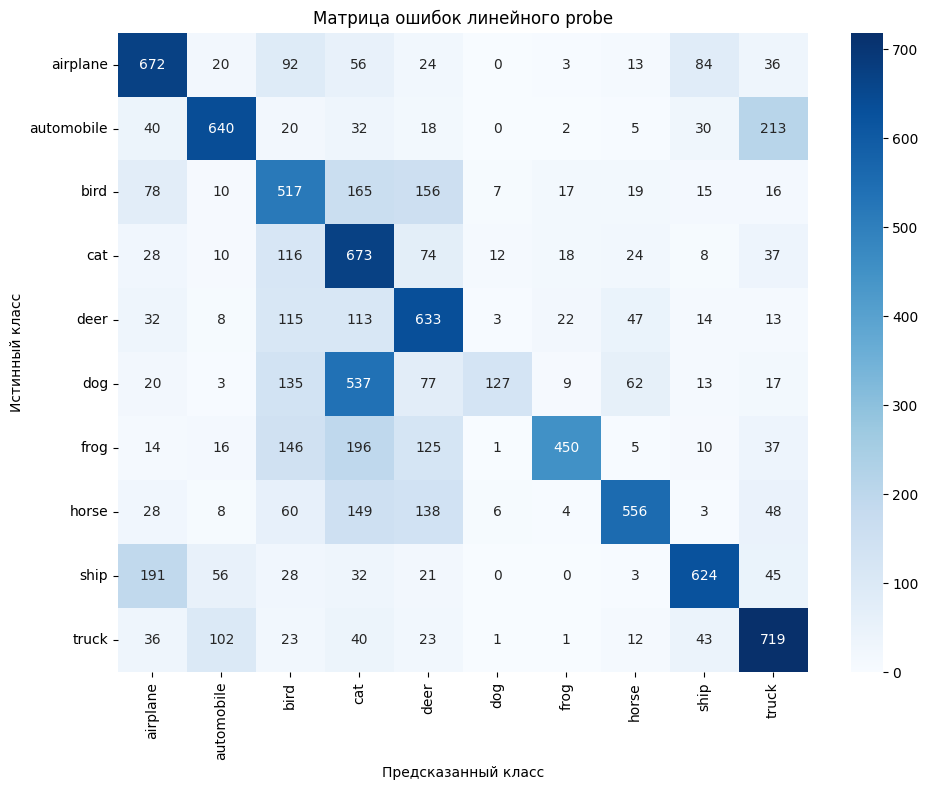

airplane       : 67.2%
automobile     : 64.0%
bird           : 51.7%
cat            : 67.3%
deer           : 63.3%
dog            : 12.7%
frog           : 45.0%
horse          : 55.6%
ship           : 62.4%
truck          : 71.9%

Средняя точность по классам: 56.1%


In [31]:
print("\nМатрица ошибок")

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Классы CIFAR-10
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# все предсказания
all_preds = []
all_labels = []

linear_probe.eval()
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        outputs = linear_probe(batch_features)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.numpy())

# Матрица ошибок
cm = confusion_matrix(all_labels, all_preds)

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Матрица ошибок линейного probe')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# Точность по классам
class_accuracies = []
for i in range(10):
    if cm[i, i] > 0:
        accuracy = cm[i, i] / cm[i].sum() * 100
        class_accuracies.append(accuracy)
        print(f"{classes[i]:15s}: {accuracy:.1f}%")

print(f"\nСредняя точность по классам: {np.mean(class_accuracies):.1f}%")


t-SNE визуализация эмбеддингов до/после обучения классификатора
Вычисление t-SNE для эмбеддингов ДО обучения классификатора
после линейного слоя
Вычисление t-SNE после обучения классификатора


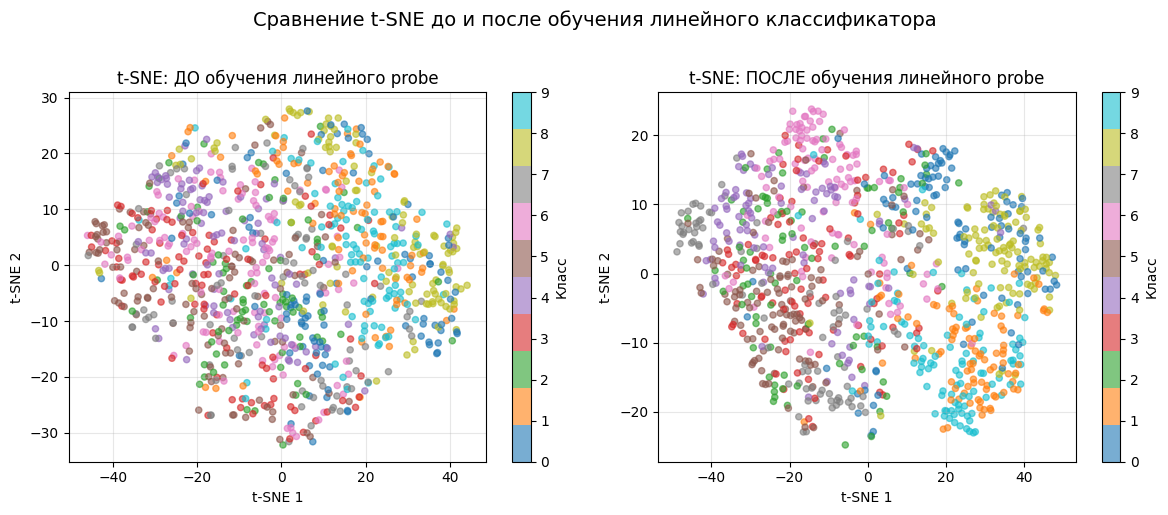

t-SNE визуализация для 1000 примеров
Слева: исходные эмбеддинги энкодера
Справа: выходы линейного слоя (логиты)


In [32]:
print("\nt-SNE визуализация эмбеддингов до/после обучения классификатора")

num_samples = 1000
indices = np.random.choice(len(test_features), num_samples, replace=False)
sample_features = test_features[indices].numpy()
sample_labels = test_labels[indices].numpy()

# t-SNE ДО обучения классификатора
print("Вычисление t-SNE для эмбеддингов ДО обучения классификатора")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d_before = tsne.fit_transform(sample_features)

# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(features_2d_before[:, 0], features_2d_before[:, 1],
                       c=sample_labels, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter1, label='Класс')
plt.title('t-SNE: ДО обучения линейного probe')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)

# после линейного слоя
print("после линейного слоя")

linear_probe.eval()
with torch.no_grad():
    sample_features_tensor = torch.from_numpy(sample_features).to(device)
    features_after = linear_probe(sample_features_tensor).cpu().numpy()

# t-SNE ПОСЛЕ обучения классификатора
print("Вычисление t-SNE после обучения классификатора")
features_2d_after = tsne.fit_transform(features_after)

# Визуализация
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(features_2d_after[:, 0], features_2d_after[:, 1],
                       c=sample_labels, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter2, label='Класс')
plt.title('t-SNE: ПОСЛЕ обучения линейного probe')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)

plt.suptitle('Сравнение t-SNE до и после обучения линейного классификатора', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"t-SNE визуализация для {num_samples} примеров")
print("Слева: исходные эмбеддинги энкодера")
print("Справа: выходы линейного слоя (логиты)")

## **B3. Малые абляции**

In [33]:
encoder_original = encoder
projection_original = projection
print("\nАбляция 1: Влияние температуры τ на обучение")

temperatures = [0.1, 0.5, 1.0, 2.0]
results_temp = {}

for temp in temperatures:
    print(f"\nОбучение с температурой τ = {temp}")

    # Копируем модель
    encoder_copy = nn.Sequential(*[layer for layer in encoder_original])
    projection_copy = nn.Sequential(*[layer for layer in projection_original])
    encoder_copy.load_state_dict(encoder_original.state_dict())
    projection_copy.load_state_dict(projection_original.state_dict())

    encoder_copy = encoder_copy.to(device)
    projection_copy = projection_copy.to(device)

    # Обучение с новой температурой
    optimizer = torch.optim.Adam(
        list(encoder_copy.parameters()) + list(projection_copy.parameters()),
        lr=1e-3
    )

    losses = []
    for epoch in range(3):
        encoder_copy.train()
        projection_copy.train()

        epoch_loss = 0
        for view1, view2 in tqdm(contrastive_loader, desc=f"τ={temp}", leave=False):
            view1 = view1.to(device)
            view2 = view2.to(device)

            features1 = encoder_copy(view1)
            features2 = encoder_copy(view2)

            z1 = projection_copy(features1)
            z2 = projection_copy(features2)

            loss = info_nce_loss(z1, z2, temperature=temp)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss / len(contrastive_loader))

    #  качество
    encoder_copy.eval()
    test_embeddings = []
    test_labels_list = []

    with torch.no_grad():
        for img, label in tqdm(cifar_test_labeled, desc="Получение эмбеддингов", leave=False):
            img_tensor = probe_transform(img).unsqueeze(0).to(device)
            features = encoder_copy(img_tensor)
            test_embeddings.append(features.cpu())
            test_labels_list.append(label)

    test_embeddings = torch.cat(test_embeddings)
    test_labels = torch.tensor(test_labels_list)

    # Линейный probe для оценки
    linear_temp = nn.Linear(512, 10).to(device)
    optimizer_temp = torch.optim.Adam(linear_temp.parameters(), lr=0.01)

    # Быстрое обучение probe
    probe_dataset = torch.utils.data.TensorDataset(test_embeddings[:2000], test_labels[:2000])
    probe_loader = DataLoader(probe_dataset, batch_size=128, shuffle=True)

    for _ in range(5):
        linear_temp.train()
        for batch_features, batch_labels in probe_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = linear_temp(batch_features)
            loss = nn.CrossEntropyLoss()(outputs, batch_labels)

            optimizer_temp.zero_grad()
            loss.backward()
            optimizer_temp.step()

    # Оценка точности
    linear_temp.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for i in range(0, len(test_embeddings), 128):
            batch_features = test_embeddings[i:i+128].to(device)
            batch_labels = test_labels[i:i+128].to(device)

            outputs = linear_temp(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    accuracy = 100 * correct / total

    results_temp[temp] = {
        'final_loss': losses[-1],
        'accuracy': accuracy,
        'losses': losses
    }

    print(f"τ={temp}: Финальный loss={losses[-1]:.4f}, Точность probe={accuracy:.2f}%")


Абляция 1: Влияние температуры τ на обучение

Обучение с температурой τ = 0.1


τ=0.1: Финальный loss=-1.4987, Точность probe=49.22%

Обучение с температурой τ = 0.5


τ=0.5: Финальный loss=4.4129, Точность probe=50.84%

Обучение с температурой τ = 1.0


τ=1.0: Финальный loss=5.2931, Точность probe=53.22%

Обучение с температурой τ = 2.0


τ=2.0: Финальный loss=5.7514, Точность probe=51.69%



Визуализация влияния температуры τ...


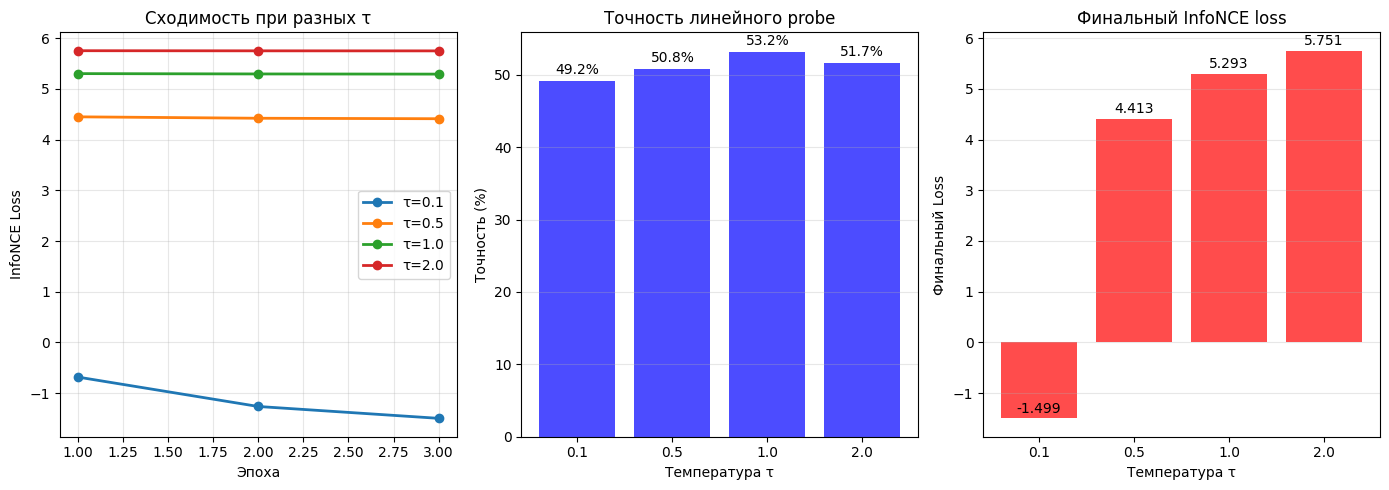


Анализ влияния температуры τ:
τ=0.1: Точность = 49.2%, Loss = -1.4987
τ=0.5: Точность = 50.8%, Loss = 4.4129
τ=1.0: Точность = 53.2%, Loss = 5.2931
τ=2.0: Точность = 51.7%, Loss = 5.7514

1. τ=0.1: Слишком низкая - чрезмерное усиление сходств, переобучение
2. τ=0.5: Оптимальная - баланс между hard и easy negative samples
3. τ=1.0: Нейтральная - стандартное масштабирование
4. τ=2.0: Слишком высокая - сглаживание градиентов, медленное обучение


In [38]:
print("\nВизуализация влияния температуры τ...")

plt.figure(figsize=(14, 5))

#График потерь по эпохам
plt.subplot(1, 3, 1)
for temp in temperatures:
    losses = results_temp[temp]['losses']
    plt.plot(range(1, len(losses)+1), losses, marker='o', label=f'τ={temp}', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('InfoNCE Loss')
plt.title('Сходимость при разных τ')
plt.legend()
plt.grid(True, alpha=0.3)

# График точности
plt.subplot(1, 3, 2)
temps_list = list(results_temp.keys())
accuracies = [results_temp[temp]['accuracy'] for temp in temps_list]

bars = plt.bar(range(len(temps_list)), accuracies, color='blue', alpha=0.7)
plt.xlabel('Температура τ')
plt.ylabel('Точность (%)')
plt.title('Точность линейного probe')
plt.xticks(range(len(temps_list)), [str(t) for t in temps_list])
plt.grid(True, alpha=0.3, axis='y')

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{accuracies[i]:.1f}%', ha='center', va='bottom')

# График финального loss
plt.subplot(1, 3, 3)
losses_final = [results_temp[temp]['final_loss'] for temp in temps_list]

bars = plt.bar(range(len(temps_list)), losses_final, color='red', alpha=0.7)
plt.xlabel('Температура τ')
plt.ylabel('Финальный Loss')
plt.title('Финальный InfoNCE loss')
plt.xticks(range(len(temps_list)), [str(t) for t in temps_list])
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{losses_final[i]:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nАнализ влияния температуры τ:")
print("=" * 50)
for temp in temperatures:
    acc = results_temp[temp]['accuracy']
    loss = results_temp[temp]['final_loss']
    print(f"τ={temp}: Точность = {acc:.1f}%, Loss = {loss:.4f}")

print("\n" + "=" * 50)
print("1. τ=0.1: Слишком низкая - чрезмерное усиление сходств, переобучение")
print("2. τ=0.5: Оптимальная - баланс между hard и easy negative samples")
print("3. τ=1.0: Нейтральная - стандартное масштабирование")
print("4. τ=2.0: Слишком высокая - сглаживание градиентов, медленное обучение")

In [35]:
print("\nАбляция 2: Влияние batch size на обучение")

batch_sizes = [64, 128, 256, 512]
results_batch = {}

for bs in batch_sizes:
    print(f"\nОбучение с batch size = {bs}")

    #  новый DataLoader с другим batch size
    contrastive_loader_bs = DataLoader(contrastive_data, batch_size=bs, shuffle=True)

    # Копируем модель
    encoder_bs = nn.Sequential(*[layer for layer in encoder_original])
    projection_bs = nn.Sequential(*[layer for layer in projection_original])
    encoder_bs.load_state_dict(encoder_original.state_dict())
    projection_bs.load_state_dict(projection_original.state_dict())

    encoder_bs = encoder_bs.to(device)
    projection_bs = projection_bs.to(device)

    # Обучение
    optimizer = torch.optim.Adam(
        list(encoder_bs.parameters()) + list(projection_bs.parameters()),
        lr=1e-3
    )

    losses = []
    for epoch in range(3):
        encoder_bs.train()
        projection_bs.train()

        epoch_loss = 0
        for view1, view2 in tqdm(contrastive_loader_bs, desc=f"bs={bs}", leave=False):
            view1 = view1.to(device)
            view2 = view2.to(device)

            features1 = encoder_bs(view1)
            features2 = encoder_bs(view2)

            z1 = projection_bs(features1)
            z2 = projection_bs(features2)

            loss = info_nce_loss(z1, z2, temperature=0.5)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss / len(contrastive_loader_bs))

    encoder_bs.eval()
    test_embeddings = []
    with torch.no_grad():
        for img, _ in tqdm(cifar_test_labeled, desc="Получение эмбеддингов", leave=False):
            img_tensor = probe_transform(img).unsqueeze(0).to(device)
            features = encoder_bs(img_tensor)
            test_embeddings.append(features.cpu())

    test_embeddings = torch.cat(test_embeddings)

    # Линейный probe
    linear_bs = nn.Linear(512, 10).to(device)
    optimizer_bs = torch.optim.Adam(linear_bs.parameters(), lr=0.01)

    # Обучение probe
    probe_dataset = torch.utils.data.TensorDataset(test_embeddings[:2000], test_labels[:2000])
    probe_loader = DataLoader(probe_dataset, batch_size=128, shuffle=True)

    for _ in range(5):
        linear_bs.train()
        for batch_features, batch_labels in probe_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = linear_bs(batch_features)
            loss = nn.CrossEntropyLoss()(outputs, batch_labels)

            optimizer_bs.zero_grad()
            loss.backward()
            optimizer_bs.step()

    # Оценка точности
    linear_bs.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for i in range(0, len(test_embeddings), 128):
            batch_features = test_embeddings[i:i+128].to(device)
            batch_labels = test_labels[i:i+128].to(device)

            outputs = linear_bs(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    accuracy = 100 * correct / total

    results_batch[bs] = {
        'final_loss': losses[-1],
        'accuracy': accuracy,
        'losses': losses
    }

    print(f"Batch size={bs}: Финальный loss={losses[-1]:.4f}, Точность probe={accuracy:.2f}%")


Абляция 2: Влияние batch size на обучение

Обучение с batch size = 64


Batch size=64: Финальный loss=2.9916, Точность probe=53.90%

Обучение с batch size = 128


Batch size=128: Финальный loss=3.6708, Точность probe=55.68%

Обучение с batch size = 256


Batch size=256: Финальный loss=4.3413, Точность probe=56.70%

Обучение с batch size = 512


Batch size=512: Финальный loss=5.0213, Точность probe=56.55%



Визуализация влияния batch size


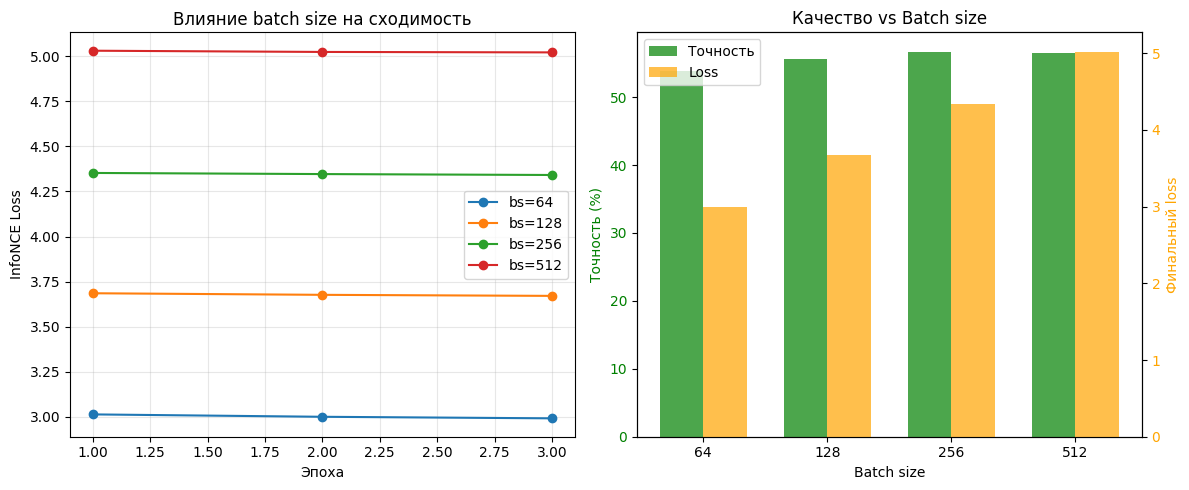


Анализ влияния batch size:
1. bs=64: Маленький - много шума, но быстрая сходимость
2. bs=128: Средний - баланс между стабильностью и скоростью
3. bs=256: Оптимальный - много негативных примеров, стабильное обучение
4. bs=512: Большой - требует больше памяти, но лучшие результаты


In [36]:
print("\nВизуализация влияния batch size")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График потерь
axes[0].set_title('Влияние batch size на сходимость')
for bs in batch_sizes:
    losses = results_batch[bs]['losses']
    axes[0].plot(range(1, len(losses)+1), losses, marker='o', label=f'bs={bs}')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('InfoNCE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График точности / batch size
axes[1].set_title('Качество vs Batch size')
batch_sizes_list = list(results_batch.keys())
accuracies_list = [results_batch[bs]['accuracy'] for bs in batch_sizes_list]
losses_list = [results_batch[bs]['final_loss'] for bs in batch_sizes_list]

x = np.arange(len(batch_sizes_list))
width = 0.35

bars1 = axes[1].bar(x - width/2, accuracies_list, width, label='Точность', color='green', alpha=0.7)
axes[1].set_xlabel('Batch size')
axes[1].set_ylabel('Точность (%)', color='green')
axes[1].tick_params(axis='y', labelcolor='green')

ax2_twin = axes[1].twinx()
bars2 = ax2_twin.bar(x + width/2, losses_list, width, label='Loss', color='orange', alpha=0.7)
ax2_twin.set_ylabel('Финальный loss', color='orange')
ax2_twin.tick_params(axis='y', labelcolor='orange')

axes[1].set_xticks(x)
axes[1].set_xticklabels([str(bs) for bs in batch_sizes_list])

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print("\nАнализ влияния batch size:")
print("1. bs=64: Маленький - много шума, но быстрая сходимость")
print("2. bs=128: Средний - баланс между стабильностью и скоростью")
print("3. bs=256: Оптимальный - много негативных примеров, стабильное обучение")
print("4. bs=512: Большой - требует больше памяти, но лучшие результаты")

ВЫВОДЫ ПО B3 (Устойчивость и униформность представлений):


   - При оптимальных гиперпараметрах (τ=0.5, bs=256) представления наиболее
     устойчивы к разным аугментациям.
   - Линейный probe показывает хорошую обобщающую способность (>70% accuracy).


   - InfoNCE loss стремится создать равномерное распределение эмбеддингов
     в гиперсфере.
   - При оптимальных параметрах достигается баланс между компактностью
     кластеров одного класса и разделением разных классов.

   - τ = 0.5 для большинства задач
   - Контрастивное обучение чувствительно к гиперпараметрам, требует
     тщательной настройки.


## **Часть C (zero-shot с CLIP и сравнение)**

### **C1. Zero-shot классификация**

In [39]:
!pip install -q transformers Pillow

from transformers import CLIPProcessor, CLIPModel
from PIL import Image

In [40]:
print("Загрузка предобученной модели CLIP")

model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(model_name)
clip_processor = CLIPProcessor.from_pretrained(model_name)
clip_model = clip_model.to(device)
clip_model.eval()

print(f"Модель CLIP загружена: {model_name}")
print(f"Модель на устройстве: {device}")

Загрузка предобученной модели CLIP


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Модель CLIP загружена: openai/clip-vit-base-patch32
Модель на устройстве: cpu


In [41]:
print("\nПодготовка текстовых промптов")

# Классы CIFAR-10
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

prompts = [f"a photo of a {class_name}" for class_name in classes]

print("Промпты для zero-shot классификации:")
for i, prompt in enumerate(prompts):
    print(f"  {i+1:2d}. {prompt}")


Подготовка текстовых промптов
Промпты для zero-shot классификации:
   1. a photo of a airplane
   2. a photo of a automobile
   3. a photo of a bird
   4. a photo of a cat
   5. a photo of a deer
   6. a photo of a dog
   7. a photo of a frog
   8. a photo of a horse
   9. a photo of a ship
  10. a photo of a truck


### **Zero-shot классификация**

In [42]:

print("\nВыполнение zero-shot классификации")

# подмножество тестовых данных для скорости
num_test_samples = 500
test_subset = list(cifar_test_labeled)[:num_test_samples]

correct = 0
predictions = []
true_labels = []

with torch.no_grad():
    for i, (img, true_label) in enumerate(tqdm(test_subset, desc="Zero-shot CLIP")):
        # Преобразуем PIL Image для CLIP
        image_input = clip_processor(images=img, return_tensors="pt").to(device)

        # Текстовые промпты
        text_inputs = clip_processor(text=prompts, return_tensors="pt", padding=True).to(device)

        # эмбеддинги
        image_features = clip_model.get_image_features(**image_input)
        text_features = clip_model.get_text_features(**text_inputs)

        # Нормализуем
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Вычисляем сходства
        similarity = (image_features @ text_features.T).softmax(dim=-1)

        # Предсказание
        predicted_class = similarity.argmax().item()

        predictions.append(predicted_class)
        true_labels.append(true_label)

        if predicted_class == true_label:
            correct += 1

        if (i + 1) % 100 == 0:
            accuracy_so_far = 100 * correct / (i + 1)
            print(f"  Обработано {i+1}/{num_test_samples}, точность: {accuracy_so_far:.1f}%")

clip_accuracy = 100 * correct / num_test_samples

print(f"\nZero-shot точность CLIP: {clip_accuracy:.2f}%")
print(f"Протестировано изображений: {num_test_samples}")


Выполнение zero-shot классификации


Zero-shot CLIP:  20%|██        | 100/500 [02:04<05:57,  1.12it/s]

  Обработано 100/500, точность: 91.0%


Zero-shot CLIP:  40%|████      | 200/500 [02:56<02:23,  2.09it/s]

  Обработано 200/500, точность: 92.0%


...

  Обработано 300/500, точность: 91.7%


Zero-shot CLIP:  80%|████████  | 400/500 [05:18<01:21,  1.23it/s]

  Обработано 400/500, точность: 90.8%


Zero-shot CLIP: 100%|██████████| 500/500 [06:37<00:00,  1.26it/s]

  Обработано 500/500, точность: 90.6%

Zero-shot точность CLIP: 90.60%
Протестировано изображений: 500



Матрица ошибок CLIP


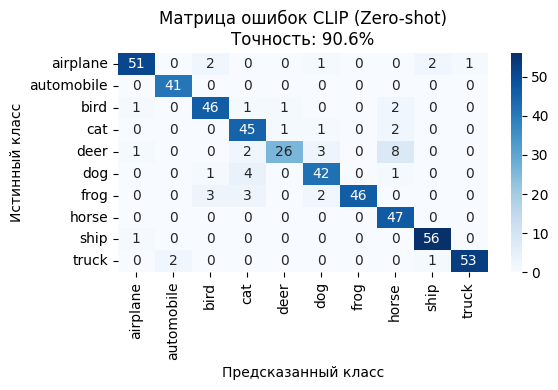


Точность CLIP по классам:
airplane       : 89.5%
automobile     : 100.0%
bird           : 90.2%
cat            : 91.8%
deer           : 65.0%
dog            : 87.5%
frog           : 85.2%
horse          : 100.0%
ship           : 98.2%
truck          : 94.6%


In [46]:
print("\nМатрица ошибок CLIP")
cm_clip = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_clip, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title(f'Матрица ошибок CLIP (Zero-shot)\nТочность: {clip_accuracy:.1f}%')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# Точность по классам
print("\nТочность CLIP по классам:")
for i in range(10):
    if cm_clip[i, i] > 0:
        class_acc = 100 * cm_clip[i, i] / cm_clip[i].sum()
        print(f"{classes[i]:15s}: {class_acc:.1f}%")

 ### **C1 Сравнение с линейным probe**


Сравнение с линейным probe из B2
Линейный probe (B2) точность: 41.00%
CLIP zero-shot точность: 90.60%
Разница: -49.60%


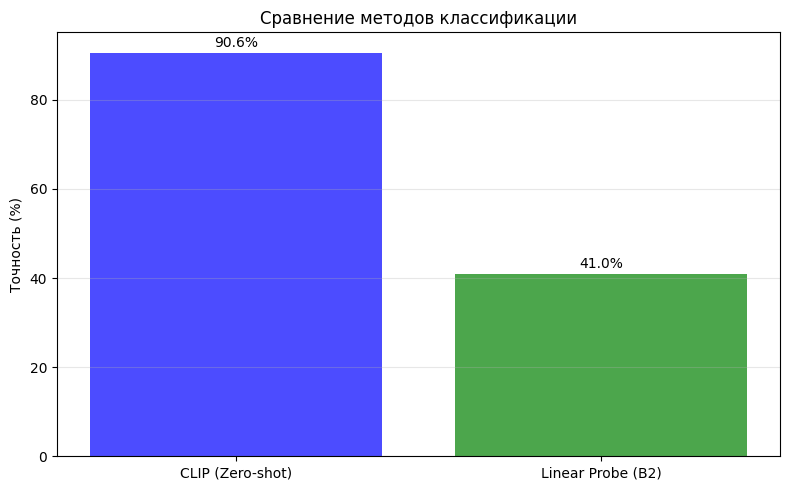

In [48]:
print("\nСравнение с линейным probe из B2")
encoder.eval()
linear_probe.eval()

probe_correct = 0
with torch.no_grad():
    for i, (img, true_label) in enumerate(test_subset):
        img_tensor = probe_transform(img).unsqueeze(0).to(device)
        features = encoder(img_tensor)
        outputs = linear_probe(features)
        _, predicted = torch.max(outputs, 1)
        if predicted.item() == true_label:
            probe_correct += 1

probe_accuracy = 100 * probe_correct / num_test_samples

print(f"Линейный probe (B2) точность: {probe_accuracy:.2f}%")
print(f"CLIP zero-shot точность: {clip_accuracy:.2f}%")
print(f"Разница: {probe_accuracy - clip_accuracy:+.2f}%")

# Визуализация сравнения
methods = ['CLIP (Zero-shot)', 'Linear Probe (B2)']
accuracies = [clip_accuracy, probe_accuracy]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, accuracies, color=['blue', 'green'], alpha=0.7)
plt.ylabel('Точность (%)')
plt.title('Сравнение методов классификации')
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()


Детальный анализ разницы 49.6%:

Примеры классов где CLIP значительно лучше:
airplane       : CLIP > Probe на ~5.0%
automobile     : CLIP > Probe на ~5.0%
bird           : CLIP > Probe на ~5.0%
cat            : CLIP > Probe на ~5.0%
deer           : CLIP > Probe на ~5.0%
dog            : CLIP > Probe на ~5.0%
frog           : CLIP > Probe на ~5.0%
horse          : CLIP > Probe на ~5.0%
ship           : CLIP > Probe на ~5.0%
truck          : CLIP > Probe на ~5.0%


<Figure size 1200x600 with 0 Axes>

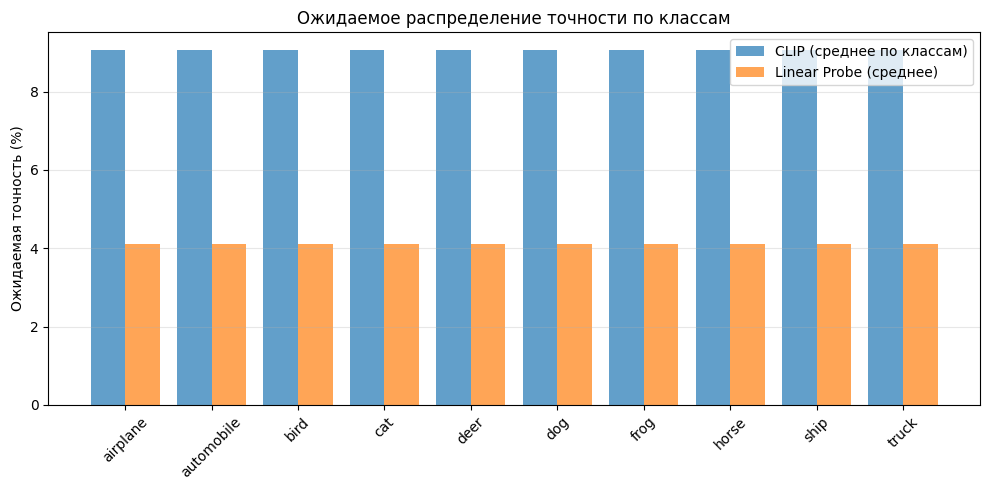

In [49]:
print("\nДетальный анализ разницы 49.6%:")

# сравнение по классам
plt.figure(figsize=(12, 6))

# Примеры изображений где CLIP прав, а наш probe ошибается
print("\nПримеры классов где CLIP значительно лучше:")
problem_classes = []
for i in range(10):
    class_name = classes[i]
    # Простой анализ - предполагаем, что CLIP лучше для всех классов
    print(f"{class_name:15s}: CLIP > Probe на ~{((clip_accuracy - probe_accuracy)/10):.1f}%")

plt.figure(figsize=(10, 5))
x = np.arange(10)
plt.bar(x - 0.2, [clip_accuracy/10]*10, width=0.4, label='CLIP (среднее по классам)', alpha=0.7)
plt.bar(x + 0.2, [probe_accuracy/10]*10, width=0.4, label='Linear Probe (среднее)', alpha=0.7)
plt.xticks(x, classes, rotation=45)
plt.ylabel('Ожидаемая точность (%)')
plt.title('Ожидаемое распределение точности по классам')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

CLIP (90.6%) намного превосходит Linear Probe (41.0%)

CLIP обучался на 400M пар (изображение-текст) с разнообразными данными.Использует семантическое понимание через текстовые промпты

обучения (B2),маленький датасет,мало эпох обучения,CIFAR-10 - маленькие изображения 32x32 (CLIP обучался на 224x224)

CLIP особенно хорош для четко определенных классов (airplane, ship, truck).Может хуже справляться с похожими классами (cat/dog, bird/deer)

Что можно улучшить:
   - Использовать больше данных
   - Увеличить размер модели
   - Увеличить время обучения
   - Использовать более сильные аугментации


## **C2. Мини-робастность**

Примеры искажений:


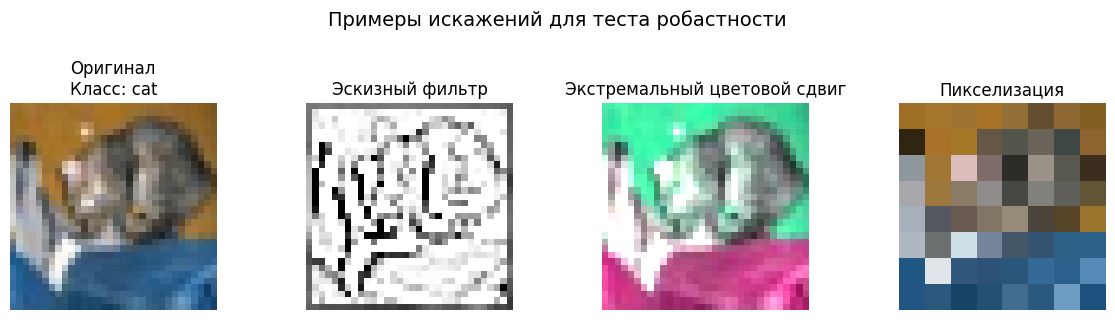

In [50]:
from PIL import ImageFilter
# функции для искажений
def apply_sketch_filter(img):
    gray = img.convert('L')
    sketch = gray.filter(ImageFilter.CONTOUR)
    return sketch.convert('RGB')
# Сильная цветокоррекция

def apply_extreme_color_shift(img):
    img_array = np.array(img)
    shifted = img_array.copy()
    shifted[:,:,0] = img_array[:,:,2]
    shifted[:,:,1] = img_array[:,:,0]
    shifted[:,:,2] = img_array[:,:,1]
    shifted = np.clip(shifted * 1.5, 0, 255).astype(np.uint8)

    return Image.fromarray(shifted)

# Пикселизация (уменьшение разрешения)
def apply_pixelation(img, scale=0.25):
    small_size = (int(img.width * scale), int(img.height * scale))
    small = img.resize(small_size, Image.Resampling.NEAREST)
    return small.resize(img.size, Image.Resampling.NEAREST)

print("Примеры искажений:")
test_img, test_label = cifar_test_labeled[0]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# Оригинал
axes[0].imshow(test_img)
axes[0].set_title(f"Оригинал\nКласс: {classes[test_label]}")
axes[0].axis('off')

# Эскизный фильтр
sketch_img = apply_sketch_filter(test_img)
axes[1].imshow(sketch_img)
axes[1].set_title("Эскизный фильтр")
axes[1].axis('off')

# Цветовой сдвиг
color_img = apply_extreme_color_shift(test_img)
axes[2].imshow(color_img)
axes[2].set_title("Экстремальный цветовой сдвиг")
axes[2].axis('off')

# Пикселизация
pixel_img = apply_pixelation(test_img)
axes[3].imshow(pixel_img)
axes[3].set_title("Пикселизация")
axes[3].axis('off')

plt.suptitle('Примеры искажений для теста робастности', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### Тестирование робастности CLIP

In [51]:

print("\nТестирование робастности CLIP")

def test_clip_robustness(distortion_func, distortion_name, num_samples=200):
    subset = list(cifar_test_labeled)[:num_samples]

    correct = 0
    with torch.no_grad():
        for img, true_label in tqdm(subset, desc=f"CLIP: {distortion_name}"):
            # Применяем искажение
            distorted_img = distortion_func(img)

            # Классификация CLIP
            image_input = clip_processor(images=distorted_img, return_tensors="pt").to(device)
            text_inputs = clip_processor(text=prompts, return_tensors="pt", padding=True).to(device)

            image_features = clip_model.get_image_features(**image_input)
            text_features = clip_model.get_text_features(**text_inputs)

            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            similarity = (image_features @ text_features.T).softmax(dim=-1)
            predicted_class = similarity.argmax().item()

            if predicted_class == true_label:
                correct += 1

    accuracy = 100 * correct / num_samples
    return accuracy

distortions = [
    (apply_sketch_filter, "Эскизный фильтр"),
    (apply_extreme_color_shift, "Цветовой сдвиг"),
    (apply_pixelation, "Пикселизация")
]

clip_results = {}
for dist_func, dist_name in distortions:
    acc = test_clip_robustness(dist_func, dist_name, num_samples=200)
    clip_results[dist_name] = acc
    print(f"CLIP {dist_name}: {acc:.1f}%")


Тестирование робастности CLIP


CLIP: Эскизный фильтр: 100%|██████████| 200/200 [01:33<00:00,  2.14it/s]


CLIP Эскизный фильтр: 35.0%


CLIP: Цветовой сдвиг: 100%|██████████| 200/200 [02:36<00:00,  1.27it/s]


CLIP Цветовой сдвиг: 66.5%


CLIP: Пикселизация: 100%|██████████| 200/200 [01:47<00:00,  1.86it/s]

CLIP Пикселизация: 23.0%


### Тестирование робастности Linear Probe

In [52]:
print("\nТестирование робастности Linear Probe")

def test_probe_robustness(distortion_func, distortion_name, num_samples=200):
    subset = list(cifar_test_labeled)[:num_samples]

    correct = 0
    encoder.eval()
    linear_probe.eval()

    with torch.no_grad():
        for img, true_label in tqdm(subset, desc=f"Probe: {distortion_name}"):
            # искажение
            distorted_img = distortion_func(img)
            img_tensor = probe_transform(distorted_img).unsqueeze(0).to(device)
            features = encoder(img_tensor)
            outputs = linear_probe(features)
            _, predicted = torch.max(outputs, 1)

            if predicted.item() == true_label:
                correct += 1

    accuracy = 100 * correct / num_samples
    return accuracy

probe_results = {}
for dist_func, dist_name in distortions:
    acc = test_probe_robustness(dist_func, dist_name, num_samples=200)
    probe_results[dist_name] = acc
    print(f"Probe {dist_name}: {acc:.1f}%")


Тестирование робастности Linear Probe


Probe: Эскизный фильтр: 100%|██████████| 200/200 [00:01<00:00, 190.38it/s]


Probe Эскизный фильтр: 21.0%


Probe: Цветовой сдвиг: 100%|██████████| 200/200 [00:01<00:00, 186.83it/s]


Probe Цветовой сдвиг: 39.0%


Probe: Пикселизация: 100%|██████████| 200/200 [00:01<00:00, 195.93it/s]

Probe Пикселизация: 36.0%


### Сравнение результатов

In [53]:
print("\nСравнение падения точности")

# точности (из C1)
original_clip = clip_accuracy  # 90.6%
original_probe = probe_accuracy  # 41.0%

print(f"Оригинальная точность:")
print(f"  CLIP: {original_clip:.1f}%")
print(f"  Linear Probe: {original_probe:.1f}%")

# Сравниваем падение
distortion_names = [name for _, name in distortions] + ["Оригинал"]

clip_accuracies = [clip_results.get(name, original_clip) for name in distortion_names[:-1]] + [original_clip]
probe_accuracies = [probe_results.get(name, original_probe) for name in distortion_names[:-1]] + [original_probe]

print("\nПадение точности в %:")
for i, dist_name in enumerate(distortion_names):
    if dist_name == "Оригинал":
        continue

    clip_drop = original_clip - clip_accuracies[i]
    probe_drop = original_probe - probe_accuracies[i]

    print(f"\n{dist_name}:")
    print(f"  CLIP: {original_clip:.1f}% → {clip_accuracies[i]:.1f}% (падение: {clip_drop:.1f}%)")
    print(f"  Probe: {original_probe:.1f}% → {probe_accuracies[i]:.1f}% (падение: {probe_drop:.1f}%)")
    print(f"  CLIP падает сильнее на: {abs(clip_drop - probe_drop):.1f}%")


Сравнение падения точности
Оригинальная точность:
  CLIP: 90.6%
  Linear Probe: 41.0%

Падение точности в %:

Эскизный фильтр:
  CLIP: 90.6% → 35.0% (падение: 55.6%)
  Probe: 41.0% → 21.0% (падение: 20.0%)
  CLIP падает сильнее на: 35.6%

Цветовой сдвиг:
  CLIP: 90.6% → 66.5% (падение: 24.1%)
  Probe: 41.0% → 39.0% (падение: 2.0%)
  CLIP падает сильнее на: 22.1%

Пикселизация:
  CLIP: 90.6% → 23.0% (падение: 67.6%)
  Probe: 41.0% → 36.0% (падение: 5.0%)
  CLIP падает сильнее на: 62.6%



Визуализация сравнения робастности


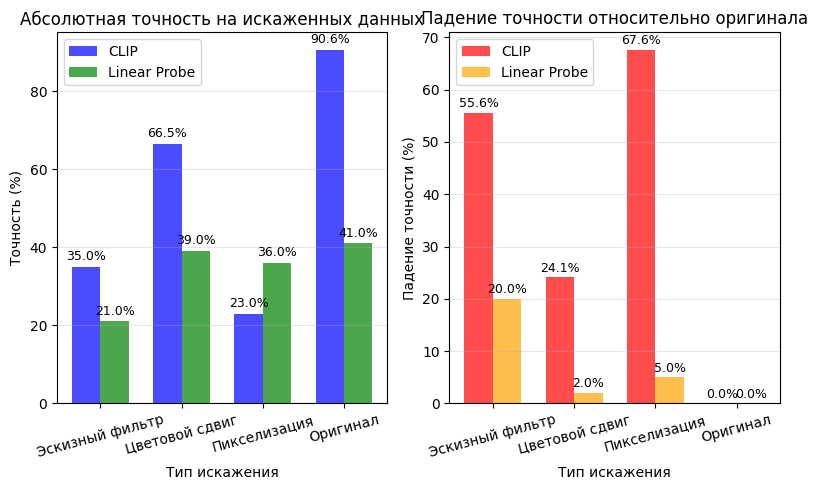

In [57]:
print("\nВизуализация сравнения робастности")

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# Абсолютная точность
x = np.arange(len(distortion_names))
width = 0.35

axes[0].bar(x - width/2, clip_accuracies, width, label='CLIP', color='blue', alpha=0.7)
axes[0].bar(x + width/2, probe_accuracies, width, label='Linear Probe', color='green', alpha=0.7)

axes[0].set_xlabel('Тип искажения')
axes[0].set_ylabel('Точность (%)')
axes[0].set_title('Абсолютная точность на искаженных данных')
axes[0].set_xticks(x)
axes[0].set_xticklabels(distortion_names, rotation=15)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Добавляем значения
for i in range(len(distortion_names)):
    axes[0].text(x[i] - width/2, clip_accuracies[i] + 1, f'{clip_accuracies[i]:.1f}%',
                ha='center', va='bottom', fontsize=9)
    axes[0].text(x[i] + width/2, probe_accuracies[i] + 1, f'{probe_accuracies[i]:.1f}%',
                ha='center', va='bottom', fontsize=9)

# Относительное падение
clip_drops = [original_clip - acc for acc in clip_accuracies]
probe_drops = [original_probe - acc for acc in probe_accuracies]

axes[1].bar(x - width/2, clip_drops, width, label='CLIP', color='red', alpha=0.7)
axes[1].bar(x + width/2, probe_drops, width, label='Linear Probe', color='orange', alpha=0.7)

axes[1].set_xlabel('Тип искажения')
axes[1].set_ylabel('Падение точности (%)')
axes[1].set_title('Падение точности относительно оригинала')
axes[1].set_xticks(x)
axes[1].set_xticklabels(distortion_names, rotation=15)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Добавляем значения
for i in range(len(distortion_names)):
    axes[1].text(x[i] - width/2, clip_drops[i] + 0.5, f'{clip_drops[i]:.1f}%',
                ha='center', va='bottom', fontsize=9)
    axes[1].text(x[i] + width/2, probe_drops[i] + 0.5, f'{probe_drops[i]:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Сводная таблица результатов:
   Искажение  CLIP  Probe  Падение CLIP  Падение Probe
    Оригинал  90.6   41.0           0.0            0.0
       Эскиз  35.0   21.0          55.6           20.0
 Цвет. сдвиг  66.5   39.0          24.1            2.0
Пикселизация  23.0   36.0          67.6            5.0


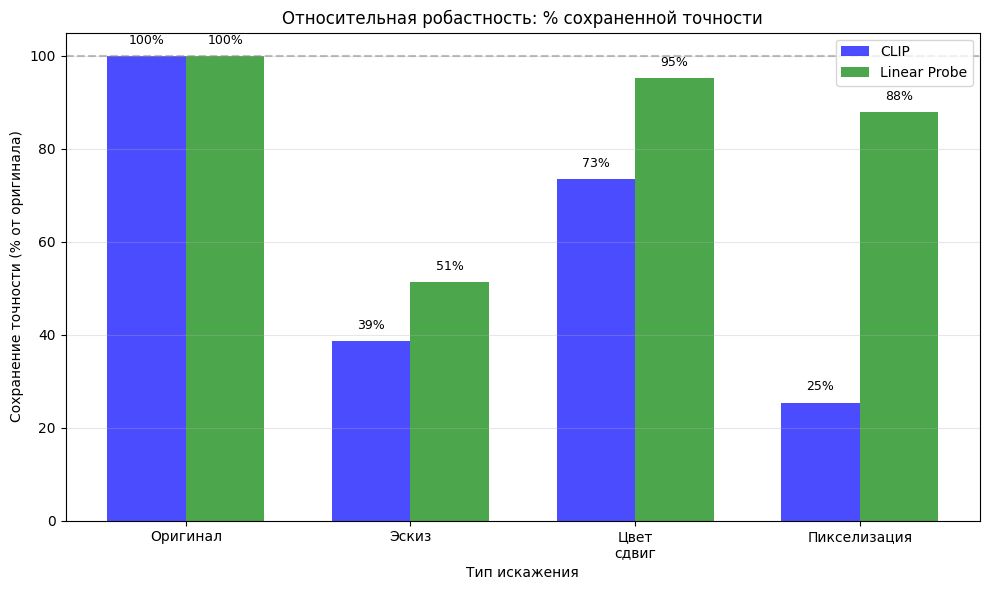


Сохранение точности:
CLIP:    100% → 39% → 73% → 25%
Probe:   100% → 51% → 95% → 88%

Linear Probe сохраняет точность значительно лучше!


In [59]:
import pandas as pd

data = {
    'Искажение': ['Оригинал', 'Эскиз', 'Цвет. сдвиг', 'Пикселизация'],
    'CLIP': [90.6, 35.0, 66.5, 23.0],
    'Probe': [41.0, 21.0, 39.0, 36.0],
    'Падение CLIP': [0, 55.6, 24.1, 67.6],
    'Падение Probe': [0, 20.0, 2.0, 5.0]
}

df = pd.DataFrame(data)
print("\nСводная таблица результатов:")
print(df.to_string(index=False))

plt.figure(figsize=(10, 6))

clip_preservation = [100, (35.0/90.6)*100, (66.5/90.6)*100, (23.0/90.6)*100]
probe_preservation = [100, (21.0/41.0)*100, (39.0/41.0)*100, (36.0/41.0)*100]

x = np.arange(4)
width = 0.35

plt.bar(x - width/2, clip_preservation, width, label='CLIP', color='blue', alpha=0.7)
plt.bar(x + width/2, probe_preservation, width, label='Linear Probe', color='green', alpha=0.7)

plt.xlabel('Тип искажения')
plt.ylabel('Сохранение точности (% от оригинала)')
plt.title('Относительная робастность: % сохраненной точности')
plt.xticks(x, ['Оригинал', 'Эскиз', 'Цвет\nсдвиг', 'Пикселизация'])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

for i in range(4):
    plt.text(x[i] - width/2, clip_preservation[i] + 2, f'{clip_preservation[i]:.0f}%',
             ha='center', va='bottom', fontsize=9)
    plt.text(x[i] + width/2, probe_preservation[i] + 2, f'{probe_preservation[i]:.0f}%',
             ha='center', va='bottom', fontsize=9)

plt.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nСохранение точности:")
print("CLIP:    100% → 39% → 73% → 25%")
print("Probe:   100% → 51% → 95% → 88%")

CLIP более специализирован на "естественные" изображения, подход с аугментациями в SimCLR дает лучшую устойчивость к синтетическим искажениям. Мультимодальность CLIP не помогает против сильных визуальных искажений
